# Efficient LLM Inference — Compression and Optimization Study

---

>
> **Authors:** Marcin Basisty | Bartosz Węgiel
> 
> **Models:** LLaMA 3.2-3B | LLaMA 3.2-1B
> 
> **Datasets:** WikiText-2 | GSM8K | TriviaQA
> 
> **Environment:** JupyterLab WFiIS Server - Python 3.12
> 
> **Testing Device:** (GPU) NVIDIA RTX A6000
> 
> **CUDA Target:** 12.1 (driver ≥ 525.60)
>

---

The goal of this project is to explore and evaluate different techniques for making Large Language Models (LLMs) smaller and faster, while measuring how much accuracy and task performance we sacrifice in the process. These optimization methods are broken down into the following operational stages:

| Stage | Method | Tool |
|-------|--------|------|
| 1 | Baseline (bf16/fp16) | HuggingFace Transformers |
| 2 | INT8 quantization | bitsandbytes LLM.int8() |
| 3 | NF4 4-bit quantization | bitsandbytes QLoRA |
| 4 | AWQ 4-bit quantization | AutoAWQ |
| 5 | Qualitative output comparison | — |
| 6 | SDPA attention | PyTorch 2.x built-in |
| 7 | FA2 attention | flash-attn |
| 8 | torch.compile (Dynamo) | PyTorch 2.x |
| 9 | Structured / unstructured pruning | torch.nn.utils.prune |
| 10 | Knowledge distillation | Custom training loop |
| 11 | Systems profiling | torch.profiler / nvidia-smi |

**Central question:** Which compression framework delivers the best accuracy-per-GB 
efficiency sweet spot, and which optimization should be selected for specific 
hardware deployment constraints?

---

## Notebook Structure

```
0.  Environment setup & hardware diagnostics (CUDA 12.1)
1.  Unified Helper Functions & Diagnostic Utilities
2.  Model Configuration Profiles
3.  Baseline Performance Evaluation — Full Precision (BF16)
4.  Post-Training Quantization (PTQ) Experiments (INT8, NF4, AWQ)
5.  Inference optimizations (SDPA, FlashAttention-2, torch.compile)
6.  Model Sparsification (Structured & Unstructured Pruning)
7.  Sequence-Level Knowledge Distillation (Student-Teacher Realignment)
8.  Systems profiling (KV Cache Optimization & Batching)
9.  Comprehensive evaluation (WikiText-2, GSM8K, TriviaQA)
10. Results — tradeoff analysis & efficiency frontier
11. Deployment recommendation
12. Reflection
13. Literature References & Appendices
```

---

---
## 0. Environment Setup — CUDA 12.1
> We hope every dependency works :'(
>

### Everything was run and tested on the JupyterLab Server provided by the faculty of Physics and Applied Computer Science AGH

All package versions are pinned to the **CUDA 12.1** wheel index.  
Minimum driver requirement: **≥ 525.60.13** (check with `nvidia-smi`).  
**Recommended:** run once in a fresh kernel, then restart.


In [ ]:
# Core ML stack
%pip install torch==2.5.1 --index-url https://download.pytorch.org/whl/cu121

# HuggingFace ecosystem
%pip install -q "transformers==4.56.2" "accelerate>=0.34.0"
%pip install "huggingface_hub>=0.34.0,<1.0" "datasets>=3.0.0" "optimum>=1.23.0"
%pip install "fsspec>=2024.6,<2026"

# Quantization back-ends
%pip install -q "bitsandbytes>=0.44.0"

In [ ]:
# Flash-Attention-2
%pip install flash-attn --no-build-isolation

In [ ]:
# FIX: torchao gets pulled in as a transitive dependency above, to resolve conflict uninstall it
%pip uninstall -y torchao

In [ ]:
# AutoAWQ — Activation-aware Weight Quantization
%pip install -q "autoawq>=0.2.5"
%pip install compressed_tensors --no-deps --no-build-isolation

In [ ]:
# Analysis & plotting
%pip install -q matplotlib seaborn pandas tabulate scipy

In [1]:
import os

# Creating directory for outputs
ROOT_DIR = "outputs"
os.makedirs(ROOT_DIR, exist_ok=True)

# == GPU selection ==========================================================
# Set before any CUDA call. Use 'nvidia-smi' to list available GPUs.
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

# == Memory allocator tuning (CUDA 12.1) ====================================
# expandable_segments avoids fragmentation on long sessions;
# max_split_size_mb caps the largest contiguous allocation cached.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:512"

# Suppress noisy HF warnings during loading
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

In [2]:
import torch
import time
import gc
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


# Main Model
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"


# Hardware check
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device         : {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    bw_gb_s = (props.memory_bandwidth / 1e9) if hasattr(props, "memory_bandwidth") else "N/A"
    print(f"GPU name       : {props.name}")
    print(f"CUDA capability: {props.major}.{props.minor}")
    print(f"VRAM (total)   : {props.total_memory / 1e9:.1f} GB")
    print(f"SM count       : {props.multi_processor_count}")
    print(f"GPUs visible   : {torch.cuda.device_count()}")
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA built with: {torch.version.cuda}")

Device         : cuda
GPU name       : NVIDIA RTX A6000
CUDA capability: 8.6
VRAM (total)   : 50.9 GB
SM count       : 84
GPUs visible   : 1
PyTorch        : 2.5.1+cu121
CUDA built with: 12.1


### Hugging Face Authentication

1. **Checks for a Saved Token:** It looks for an environment variable named `HF_TOKEN`. 
2. **Fallback Secure Input:** If it doesn't find one, it securely prompts to type or paste your token manually.
3. **Logs In:** It authenticates Jupyter session with the Hugging Face Hub, allowing to seamlessly download gated models like LLaMA 3.2.
4. **Provided Token:** We provided our personal token, so the code will just work.

In [3]:
from huggingface_hub import login

hf_token = os.environ.get("HF_TOKEN")
if not hf_token:
    from getpass import getpass
    hf_token = "Your_hugging_face_token"
    
login(token=hf_token)

### Tokenizer Initialization & Padding Configuration

This cell loads the tokenizer for the chosen model (`MODEL_ID`). It sets the `tokenizer.pad_token` to the end-of-text token if not already defined, ensuring the tokenizer can pad inputs correctly (required for batch inference). It also prints the vocabulary size and model’s maximum context length.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
print(f"Vocab size : {tokenizer.vocab_size:,}")
print(f"Model max  : {tokenizer.model_max_length}")

Vocab size : 128,000
Model max  : 131072


---
## 1. Unified Helper Functions & Diagnostic Utilities

All measurement utilities are defined here and reused across every experiment stage.

### Prompt Formatting and Chat Template

The Llama 3 Instruct models expect conversations to be formatted using Meta's chat template, which consists of special tokens that mark:

- The beginning of the conversation.
- System instructions that define model behavior.
- User messages containing the task or question.
- Assistant responses to be generated by the model.

In this notebook, a helper function is defined to manually construct prompts using the official Llama 3 Instruct template. This ensures that all experiments use a consistent input format across different model variants and quantization methods.

The template inserts a system message (`"You are a helpful assistant"`) followed by the user prompt and prepares the conversation for generation by opening the assistant response section. Standardizing prompt formatting is important because even small differences in prompt structure can affect model outputs and benchmarking results.

In [5]:
# Prompt formatting (LLaMA-3 instruct template)
def format_prompt(prompt: str) -> str:
    """Apply the LLaMA-3 instruct chat template manually."""
    return (
        "<|begin_of_text|>"
        "<|start_header_id|>system<|end_header_id|>\n\n"
        "You are a helpful assistant.<|eot_id|>"
        "<|start_header_id|>user<|end_header_id|>\n\n"
        f"{prompt}<|eot_id|>"
        "<|start_header_id|>assistant<|end_header_id|>\n\n"
    )

### VRAM & Memory Utilities

The cell below defines utility functions for GPU memory measurement and cleanup:

- `get_vram_gb()`: returns the peak allocated GPU memory (GB) since the last reset.
- `reset_vram_peak()`: resets PyTorch’s peak memory tracker.
- `model_size_gb()`: computes the model’s parameter size in GB (on-disk equivalent).
- `check_vram(label)`: prints current GPU memory (allocated, reserved, free).
- `free_model(model)`: moves a model to CPU, deletes it, and empties the cache.

These helpers allow us to monitor GPU usage throughout the experiment (for example, before/after loading models) and to explicitly release GPU memory. This prevents out-of-memory (OOM) when switching between models. 

In [6]:
# VRAM & memory utilities
def get_vram_gb() -> float:
    """Peak allocated VRAM in GB since last reset_vram_peak()."""
    return torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0

def reset_vram_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def model_size_gb(model) -> float:
    """Sum of all parameter tensors in GB (on-disk equivalent)."""
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1e9

def check_vram(label: str = ""):
    if not torch.cuda.is_available():
        return
    alloc  = torch.cuda.memory_allocated()  / 1e9
    reserv = torch.cuda.memory_reserved()   / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    tag    = f"[{label}] " if label else ""
    print(f"{tag}VRAM — alloc: {alloc:.2f} GB | reserved: {reserv:.2f} GB | "
          f"free: {total - alloc:.2f} GB / {total:.1f} GB total")

def free_model(model):
    """Release model from GPU; call as: model = free_model(model)."""
    try:
        model.cpu()
    except Exception:
        pass
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    return None

### Throughput & latency measurement

This cell defines `measure_throughput(model, tokenizer, prompt, ...)`, which benchmarks raw autoregressive inference performance using a manual KV-cache decoding loop.

For each run, the function:

1. Performs a **prefill pass** over the entire prompt to initialize the KV cache and produce the first generated token.
2. Measures the prefill latency as **TTFT (Time To First Token)**.
3. Continues generation one token at a time using the cached keys and values, timing every decode step individually.
4. Computes **decode throughput (tokens/sec)** from the measured decode-step durations rather than from a single end-to-end generation call.

Reported metrics include:

- **Tokens/sec**: average decode-only throughput (generation speed after prefill).
- **TTFT (ms)**: prefill latency, representing the cost of processing the full prompt and producing the first token.
- **TTFT Std Dev (ms)**: variability of TTFT across benchmark runs.
- **Total Time (s)**: end-to-end generation time (prefill + decode).
- **Total Time Std Dev (s)**: variability of total generation time across runs.

The benchmark measures the model's raw forward-pass performance and KV-cache efficiency while avoiding the additional Python overhead, stopping criteria, logits processors, and sampling logic used by Hugging Face's `generate()` API. As a result, throughput measurements may be slightly more optimistic than those obtained from end-to-end `generate()` calls, but they provide a more precise view of model inference performance.

In the report, these metrics are compared across BF16 and quantized models to evaluate the impact of quantization on latency and generation throughput.

In [7]:
def measure_throughput(model, tokenizer, prompt: str,
                        n_tokens: int = 200, n_runs: int = 3,
                        warmup_runs: int = 1) -> dict:
    """
    Throughput + latency benchmark using a manual KV-cache decode loop.

    Unlike approaches that call generate() once for 1 token and again for
    n_tokens and subtract the two, this times every forward pass
    individually within a single generation. TTFT is the prefill forward
    pass; decode throughput is computed from the actual per-step times of
    every subsequent single-token forward pass. No subtraction, no
    duplicated prefill computation, no clamping of a possibly-negative value.

    Trade-off: this bypasses HF's generate() wrapper (stopping criteria,
    logits processors, sampling logic), so it measures raw model forward-pass
    speed. If you need timing for the actual generate() call as used in
    production (including its Python-level overhead), this will be
    marginally optimistic versus calling generate() directly. Greedy
    decoding and batch size 1 are assumed.

    Returns:
        tokens_per_sec    : average decode-only throughput (tokens/s)
        ttft_ms           : average time-to-first-token (ms), prefill only
        ttft_std_ms       : std dev of TTFT across runs (ms)
        total_time_s      : average total generation time (prefill + decode)
        total_time_std_s  : std dev of total generation time across runs
    """
    model.eval()

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    formatted = format_prompt(prompt)
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)
    input_ids = inputs["input_ids"]
    attention_mask = inputs.get("attention_mask", torch.ones_like(input_ids))
    eos_id = tokenizer.eos_token_id

    def sync():
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    @torch.no_grad()
    def run_once():
        cur_attention_mask = attention_mask
        past_key_values = None

        # Prefill: one forward pass over the full prompt -> first new token.
        sync()
        t0 = time.perf_counter()
        out = model(
            input_ids=input_ids,
            attention_mask=cur_attention_mask,
            use_cache=True,
        )
        sync()
        ttft_s = time.perf_counter() - t0

        next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
        past_key_values = out.past_key_values
        cur_attention_mask = torch.cat(
            [cur_attention_mask, torch.ones_like(next_token)], dim=-1
        )

        # Decode: one forward pass per subsequent token, timed individually.
        step_times = []
        for _ in range(n_tokens - 1):
            if eos_id is not None and next_token.item() == eos_id:
                break
            sync()
            ts = time.perf_counter()
            out = model(
                input_ids=next_token,
                attention_mask=cur_attention_mask,
                past_key_values=past_key_values,
                use_cache=True,
            )
            sync()
            step_times.append(time.perf_counter() - ts)

            next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
            past_key_values = out.past_key_values
            cur_attention_mask = torch.cat(
                [cur_attention_mask, torch.ones_like(next_token)], dim=-1
            )

        decode_time_s = sum(step_times)
        decode_tokens = len(step_times)
        tps = decode_tokens / decode_time_s if decode_time_s > 0 else 0.0
        total_time_s = ttft_s + decode_time_s

        return ttft_s * 1000.0, tps, total_time_s

    for _ in range(warmup_runs):
        run_once()

    ttft_list, tps_list, total_list = [], [], []
    for _ in range(n_runs):
        ttft_ms, tps, total_time_s = run_once()
        ttft_list.append(ttft_ms)
        tps_list.append(tps)
        total_list.append(total_time_s)

    return {
        "tokens_per_sec":   round(float(np.mean(tps_list)), 2),
        "ttft_ms":          round(float(np.mean(ttft_list)), 2),
        "ttft_std_ms":      round(float(np.std(ttft_list)), 2),
        "total_time_s":     round(float(np.mean(total_list)), 2),
        "total_time_std_s": round(float(np.std(total_list)), 2),
    }

### Perplexity Evaluation on WikiText-2

Model compression techniques such as quantization and distillation reduce memory consumption and computational cost, but they may also degrade the model's ability to predict text accurately. To quantify this effect, each model is evaluated using **perplexity**, one of the most widely used intrinsic metrics for language modeling.

Perplexity measures how well a language model predicts the next token in a sequence. Lower perplexity indicates that the model assigns higher probability to the correct continuation of the text and therefore retains more of its original language modeling capability.

The WikiText-2 benchmark dataset, a standard evaluation corpus containing English Wikipedia articles. To obtain a realistic estimate of model quality, perplexity is computed using a **sliding-window evaluation strategy**. Since transformer models have a limited context length, long documents are processed in overlapping windows, ensuring that tokens are evaluated with access to as much preceding context as possible while avoiding repeated penalization of the same tokens.

The evaluation procedure:

1. Loads a subset of the WikiText-2 test split.
2. Tokenizes the text into a continuous sequence.
3. Processes the sequence using overlapping windows.
4. Computes the negative log-likelihood (NLL) of target tokens.
5. Aggregates losses across the dataset.
6. Converts the average NLL into perplexity.

This metric will later be used to compare the quality impact of different compression methods, including INT8 quantization, NF4 quantization, AWQ quantization, and knowledge distillation. While memory usage and inference speed measure efficiency, perplexity provides an estimate of how much language modeling performance is preserved after compression.

In [8]:
# WikiText-2 perplexity
def compute_perplexity(model, tokenizer, n_samples: int = 50,
                       stride: int = 512, max_len: int = 1024) -> float:
    """
    Sliding-window perplexity on WikiText-2 test split.
    Stride avoids re-penalising context tokens. 
    """
    dataset  = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
    text     = "\n\n".join(dataset["text"][:n_samples])
    encodings = tokenizer(text, return_tensors="pt")

    nlls, prev_end = [], 0
    seq_len        = encodings.input_ids.size(1)
    model.eval()

    with torch.no_grad():
        for begin in range(0, seq_len, stride):
            end        = min(begin + max_len, seq_len)
            target_len = end - max(begin, prev_end)
            input_ids  = encodings.input_ids[:, begin:end].to(model.device)
            labels     = input_ids.clone()
            labels[:, :-target_len] = -100
            out = model(input_ids, labels=labels)
            nlls.append(out.loss * target_len)
            prev_end = end
            if end == seq_len:
                break

    return round(torch.exp(torch.stack(nlls).sum() / prev_end).item(), 3)

### Reasoning Performance Evaluation on GSM8K

While perplexity measures a model's ability to predict natural language, it does not necessarily reflect the model's reasoning capabilities. Modern Large Language Models are increasingly used for tasks that require multi-step problem solving, arithmetic reasoning, and logical inference. Therefore, an additional benchmark is required to assess how well compressed models retain these capabilities after quantization or distillation.

This reasoning performance is being evaluated by using the **GSM8K (Grade School Math 8K)** benchmark, one of the most widely used datasets for assessing mathematical reasoning in language models. The dataset contains thousands of word problems that require multiple reasoning steps to reach a correct numerical answer.

The evaluation is performed in a **zero-shot setting**, meaning that no examples are provided in the prompt. Each question is presented directly to the model using the same instruction template employed throughout the notebook. The model generates an answer, and the final numerical prediction is extracted and compared against the ground-truth solution.

The evaluation procedure:

1. Loads a subset of GSM8K test questions.
2. Formats each question using the Llama 3 instruction template.
3. Generates a deterministic response using greedy decoding.
4. Extracts the final numerical answer from the generated text.
5. Compares the prediction against the reference answer.
6. Computes overall accuracy as the percentage of correctly solved problems.

Unlike perplexity, which measures language modeling quality, GSM8K accuracy evaluates a model's ability to perform structured reasoning. This distinction is important because some compression methods may preserve fluency while degrading reasoning performance. By combining perplexity and GSM8K evaluations, the notebook assesses both linguistic quality and reasoning capability, providing a more comprehensive view of the trade-offs introduced by model compression.

In [9]:
# GSM8K zero-shot accuracy
import re

def evaluate_gsm8k(model, tokenizer, n_samples: int = 100) -> float:
    dataset = load_dataset("openai/gsm8k", "main", split="test")
    samples = dataset.select(range(n_samples))
    correct = 0

    for item in samples:
        formatted = format_prompt(item["question"])
        inputs    = tokenizer(formatted, return_tensors="pt",
                              truncation=True, max_length=512).to(model.device)
        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Strip prompt tokens before decoding
        response = tokenizer.decode(
            out[0][input_len:],
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        ).strip()

        # Ground truth: number after ####
        gt_match = re.findall(r"[-+]?\d[\d,]*\.?\d*", item["answer"].split("####")[-1].strip())
        
        # Prediction: last number in the generated response
        pred_match = re.findall(r"[-+]?\d[\d,]*\.?\d*", response)

        if gt_match and pred_match:
            # Normalise: remove commas (1,000 -> 1000)
            gt   = gt_match[0].replace(",", "")
            pred = pred_match[-1].replace(",", "")
            if gt == pred:
                correct += 1

    return round(correct / n_samples * 100, 2)

### Factual Knowledge Evaluation on TriviaQA

Compression techniques such as quantization and distillation can affect different aspects of model performance in different ways. While perplexity evaluates language modeling ability and GSM8K measures reasoning performance, neither directly assesses a model's ability to recall factual knowledge. To evaluate this dimension, the notebook uses the **TriviaQA** benchmark.

TriviaQA is a large-scale question-answering dataset containing fact-based questions covering a broad range of topics, including history, science, geography, literature, entertainment, and current events. The benchmark is commonly used to assess whether language models can retrieve and generate correct factual information from their internal knowledge.

In this evaluation, the model is presented with a question and instructed to provide a concise answer. The task is performed in a **closed-book setting**, meaning that no external documents or retrieval mechanisms are provided. The model must therefore rely entirely on the knowledge encoded within its parameters.

The evaluation procedure:

1. Loads a subset of the TriviaQA validation dataset.
2. Formats each question using the Llama 3 instruction template.
3. Requests a short factual answer from the model.
4. Generates a deterministic response using greedy decoding.
5. Normalizes both predicted and reference answers to remove differences in capitalization, punctuation, and formatting.
6. Compares the prediction against all accepted answer aliases provided by the dataset.
7. Computes overall accuracy as the percentage of correctly answered questions.

Unlike GSM8K, which primarily evaluates reasoning ability, TriviaQA measures factual knowledge retention. This distinction is particularly important when studying model compression because some techniques may preserve reasoning performance while degrading factual recall, or vice versa.

Together with WikiText-2 perplexity and GSM8K accuracy, TriviaQA provides a complementary evaluation dimension:

| Metric | Measures |
|----------|----------|
| WikiText-2 Perplexity | Language modeling quality |
| GSM8K Accuracy | Mathematical and multi-step reasoning |
| TriviaQA Accuracy | Factual knowledge retention |

By combining these benchmarks, the notebook evaluates whether compression methods reduce memory and computational requirements while preserving linguistic quality, reasoning capability, and factual knowledge.

In [10]:
# TriviaQA accuracy
def normalize_answer(s: str) -> str:
    import string
    s = s.lower().strip()
    for art in [" a ", " an ", " the "]:
        s = s.replace(art, " ")
    s = s.translate(str.maketrans("", "", string.punctuation))
    return " ".join(s.split())


def evaluate_triviaqa(model, tokenizer, n_samples: int = 100) -> float:
    dataset = load_dataset(
        "mandarjoshi/trivia_qa", 
        "rc.nocontext", 
        split="validation",
    )
    samples = dataset.select(range(n_samples))
    correct = 0

    for item in samples:
        question = item["question"]
        aliases  = [normalize_answer(a) for a in item["answer"]["aliases"]]

        formatted = format_prompt(
            f"Answer the following question in as few words as possible.\n{question}"
        )
        inputs    = tokenizer(formatted, return_tensors="pt",
                              truncation=True, max_length=256).to(model.device)
        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=64,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        response = tokenizer.decode(
            out[0][input_len:],
            skip_special_tokens=True,
        ).strip()

        # Take only the first line — model sometimes explains after answering
        pred = normalize_answer(response.split("\n")[0])

        # Match if: exact, pred contains alias, or alias contains pred
        if any(
            pred == a or
            (len(a) > 3 and a in pred) or
            (len(pred) > 3 and pred in a)
            for a in aliases
        ):
            correct += 1

    return round(correct / n_samples * 100, 2)

## Experimental Logging and Result Management

A comprehensive compression study involves evaluating multiple model variants across several metrics, including memory consumption, model size, inference throughput, perplexity, reasoning accuracy, and factual knowledge retention. To ensure reproducibility and facilitate comparison between experiments, a centralized result management system is implemented.

This section defines the infrastructure used to record, store, and maintain evaluation results throughout the notebook. Rather than manually collecting metrics after each experiment, all measurements are automatically logged into a structured results table and periodically saved to disk.

The primary metrics recorded for each model include:

| Metric | Purpose |
|----------|----------|
| VRAM Usage | GPU memory required during inference |
| Model Size | Storage footprint of the compressed model |
| Tokens/sec | Generation throughput |
| TTFT (Time-To-First-Token) | Inference responsiveness |
| Perplexity | Language modeling quality |
| GSM8K Accuracy | Mathematical reasoning performance |
| TriviaQA Accuracy | Factual knowledge retention |

By maintaining a centralized results ledger, the notebook can systematically compare BF16, INT8, NF4, AWQ, GPTQ, and distilled models using a common evaluation framework.

---

## Resource Cleanup and Memory Management

Large Language Models can occupy several gigabytes of GPU memory, particularly when multiple model variants are loaded sequentially within the same notebook session. Without proper cleanup, memory fragmentation and residual allocations may accumulate, eventually causing out-of-memory (OOM) errors and invalidating benchmark results.

To ensure fair and reproducible measurements, a dedicated cleanup routine is implemented. The routine identifies previously loaded model instances, releases their associated GPU resources, clears cached allocations, and synchronizes the CUDA runtime before subsequent experiments begin.

This step is particularly important because the notebook repeatedly loads and evaluates:

- BF16 baseline models
- INT8 quantized models
- NF4 quantized models
- GPTQ quantized models
- AWQ quantized models
- Distilled student models
- Profiling and benchmarking models

Performing explicit cleanup between experiments helps guarantee that memory measurements reflect only the currently evaluated model rather than residual allocations from previous runs.

The cleanup procedure therefore acts as an experimental control mechanism, ensuring that VRAM measurements, throughput benchmarks, and latency evaluations remain comparable across all compression methods.

In [46]:
# Results ledger & logging
RESULTS: list[dict] = []
RESULTS_CSV = ROOT_DIR + "/results.csv"

# Resume support: if a previous (partial) run left a results.csv behind
if os.path.exists(RESULTS_CSV):
    RESULTS = pd.read_csv(RESULTS_CSV).to_dict("records")
    print(f"Loaded {len(RESULTS)} previous result(s) from {RESULTS_CSV}")

def log_result(label: str,
               vram_gb: float,
               size_gb: float,
               throughput: dict,
               perplexity: float,
               gsm8k_acc: float | None = None,
               triviaqa_acc: float | None = None):

    RESULTS[:] = [r for r in RESULTS if r["Label"] != label]
    RESULTS.append({
        "Label"          : label,
        "VRAM (GB)"      : round(vram_gb,  2),
        "Size (GB)"      : round(size_gb,  2),
        "Tokens/sec"     : throughput["tokens_per_sec"],
        "TTFT (ms)"      : throughput["ttft_ms"],
        "Perplexity"     : perplexity,
        "GSM8K (%)"      : gsm8k_acc,
        "TriviaQA (%)"   : triviaqa_acc,
    })

    pd.DataFrame(RESULTS).to_csv(RESULTS_CSV, index=False)
    print(pd.DataFrame(RESULTS).to_string(index=False))

def force_full_cleanup():
    """Release all known model variables from GPU memory."""
    
    known = ["model_bf16","model_int8","model_nf4","model_gptq","model_awq",
             "model_profile","model_distilled","student","teacher","m","model"]
    for name in known:
        if name in globals() and globals()[name] is not None:
            print(f"  freeing {name}…")
            globals()[name] = free_model(globals()[name])
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    check_vram("after cleanup")

Loaded 11 previous result(s) from outputs/results.csv


---
## 2. Model Configuration Profiles

The primary objective of this study is to investigate the trade-offs between model quality, memory consumption, and inference performance when applying different compression techniques to Large Language Models (LLMs). To achieve this, multiple model configurations are defined and evaluated under a common benchmarking framework.

The experiments compare both full-precision and compressed variants of the same model family. Each configuration represents a different point in the efficiency–accuracy design space, allowing the study to quantify how much memory and computational cost can be reduced while preserving model capabilities.

The following configurations are evaluated:

| Configuration | Description | Purpose |
|--------------|-------------|----------|
| BF16 | Brain Floating Point 16-bit precision | Reference baseline |
| INT8 | LLM.int8 quantization | Moderate compression with minimal quality degradation |
| NF4 | 4-bit NormalFloat quantization (QLoRA) | Aggressive compression for memory-efficient deployment |
| AWQ | Activation-Aware Weight Quantization | State-of-the-art post-training quantization |
| SDPA | Scaled Dot Product Attention | Efficient attention implementation available in PyTorch |
| Flash Attention 2 | Optimized attention kernel | High-performance attention implementation |

The BF16 model serves as the baseline against which all compressed models are compared. Since BF16 retains most of the numerical precision of the original model while reducing memory usage relative to FP32, it provides a practical reference point for modern inference workloads.

The INT8 and NF4 configurations are implemented using the BitsAndBytes framework. These methods reduce the precision of model weights, lowering memory requirements and potentially increasing throughput. However, quantization may introduce approximation errors that can affect language modeling quality, reasoning performance, and factual knowledge retention.

The AWQ configuration represents a more advanced quantization approach that selectively preserves important weights based on activation statistics. This method aims to achieve compression ratios similar to 4-bit quantization while maintaining higher output quality.

---

### Attention Mechanism Variants

Transformer inference is heavily influenced by the implementation of the attention mechanism. Recent advances have introduced optimized attention kernels that significantly reduce memory bandwidth requirements and improve computational efficiency.

Two attention implementations are evaluated:

#### Scaled Dot Product Attention (SDPA)

SDPA is the optimized attention implementation provided by PyTorch. It automatically selects efficient kernels and serves as a strong baseline for modern transformer inference.

#### Flash Attention 2

Flash Attention 2 is a highly optimized attention algorithm designed to reduce memory movement and improve GPU utilization. Because attention often dominates transformer execution time, Flash Attention can substantially improve inference throughput, particularly for long context lengths.

Comparing these implementations allows the study to assess whether attention-level optimizations provide additional performance gains beyond those achieved through model compression alone.

---

### Evaluation Prompt

To ensure fair comparison between model variants, all inference benchmarks use the same prompt:

> "Explain the theory of general relativity in simple terms."

This prompt was selected because it requires the model to generate a coherent multi-sentence explanation involving scientific concepts while remaining understandable to a general audience. The task exercises both language generation and factual knowledge, producing a realistic workload for measuring latency, throughput, memory usage, and output quality.

Using a fixed prompt across all experiments ensures that differences in measured performance can be attributed to the model configuration rather than variations in input complexity.


In [12]:
# BF16 baseline
BF16_KWARGS = dict(
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

# INT8 (LLM.int8)
# Mixed-precision: outlier channels in fp16, remainder in int8.
INT8_CONFIG = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.float16,
)
INT8_KWARGS = dict(quantization_config=INT8_CONFIG, device_map="auto")

# NF4 4-bit (QLoRA)
NF4_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)
NF4_KWARGS = dict(quantization_config=NF4_CONFIG, device_map="auto")

# AWQ — compressed-tensors format
# Quantised from Llama-3.2-3B-Instruct.
AWQ_MODEL_ID  = "cyankiwi/Llama-3.2-3B-Instruct-AWQ-INT4"

# Scaled Dot Product Attention
SDPA_KWARGS = dict(
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
)

# Flash-Attention-2
FA2_KWARGS = dict(
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="flash_attention_2",
)

# Main prompt of which the models will be evaluated
PROMPT = "Explain the theory of general relativity in simple terms:"

---
## 3. Baseline Performance Evaluation — Full Precision (BF16)

This experiment establishes the reference point for all subsequent compression studies. The model is loaded using the BF16 (Brain Floating Point 16-bit) numerical format, which is widely adopted in modern LLM inference due to its favorable balance between numerical precision and memory efficiency.

The BF16 model serves as the baseline against which all quantized and distilled variants will be compared. Since no weight compression is applied, the resulting measurements represent the expected quality and performance of the original model.

In [18]:
reset_vram_peak()
check_vram("before BF16 load")

model_bf16 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **BF16_KWARGS)
model_bf16.eval()
check_vram("BF16 loaded")

n_params = sum(p.numel() for p in model_bf16.parameters())
print(f"Parameters : {n_params / 1e9:.3f} B")
print(f"dtype      : {next(model_bf16.parameters()).dtype}")

throughput_bf16 = measure_throughput(model_bf16, tokenizer, PROMPT)
print(f"\nThroughput : {throughput_bf16['tokens_per_sec']} tok/s")
print(f"TTFT       : {throughput_bf16['ttft_ms']} ms (±{throughput_bf16['ttft_std_ms']} ms)")

perplexity_bf16 = compute_perplexity(model_bf16, tokenizer)
gsm8k_bf16      = evaluate_gsm8k(model_bf16, tokenizer)
triviaqa_bf16   = evaluate_triviaqa(model_bf16, tokenizer)
vram_bf16       = get_vram_gb()
size_bf16       = model_size_gb(model_bf16)

log_result("BF16 (baseline)", vram_bf16, size_bf16,
           throughput_bf16, perplexity_bf16, gsm8k_bf16, triviaqa_bf16)

model_bf16 = free_model(model_bf16)
check_vram("after freeing BF16")

[before BF16 load] VRAM — alloc: 0.00 GB | reserved: 0.00 GB | free: 50.93 GB / 50.9 GB total


2026-06-19 10:02:42.562366: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 10:02:42.572005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 10:02:42.581184: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 10:02:42.583482: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 10:02:42.591260: I tensorflow/core/platform/cpu_feature_guar

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[BF16 loaded] VRAM — alloc: 6.43 GB | reserved: 6.44 GB | free: 44.50 GB / 50.9 GB total
Parameters : 3.213 B
dtype      : torch.bfloat16

Throughput : 76.27 tok/s
TTFT       : 14.0 ms (±0.03 ms)


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

          Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
     INT8 (bnb)       5.44       3.61       31.35      52.52           1.29      10.020       57.0          54.0
NF4 4-bit (bnb)       6.89       2.20       59.07      25.92           0.05      10.534       67.0          43.0
BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
[after freeing BF16] VRAM — alloc: 0.01 GB | reserved: 0.02 GB | free: 50.92 GB / 50.9 GB total


---
## 4. Post-Training Quantization (PTQ) Experiments (INT8, NF4, AWQ)

### 4a. INT8 — bitsandbytes LLM.int8()

This experiment evaluates the impact of 8-bit weight quantization using the LLM.int8 algorithm implemented in the BitsAndBytes library.

Large Language Models typically store parameters using 16-bit or 32-bit floating-point representations. Although these formats provide high numerical precision, they also require substantial memory resources during inference. Quantization reduces memory requirements by representing weights using lower-precision numerical formats.

The LLM.int8 approach performs post-training quantization by converting the majority of model weights from floating-point values to 8-bit integers. To minimise accuracy degradation, the method identifies activation outliers and processes them using higher precision arithmetic while the remaining computations are executed in INT8 format. This mixed-precision strategy preserves important information while significantly reducing memory usage.

From a theoretical perspective, moving from 16-bit to 8-bit representations approximately halves the memory required to store model weights. Reduced memory bandwidth requirements may also improve inference throughput, since fewer bytes must be transferred between GPU memory and compute units.

However, quantization introduces approximation errors because a finite set of integer values must represent a continuous range of floating-point numbers. These errors may affect language modelling quality, reasoning performance, and factual knowledge retention.

In [19]:
reset_vram_peak()
check_vram("before INT8 load")

model_int8 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **INT8_KWARGS)
model_int8.eval()
check_vram("INT8 loaded")

print(f"Parameters : {sum(p.numel() for p in model_int8.parameters()) / 1e9:.3f} B")

throughput_int8 = measure_throughput(model_int8, tokenizer, PROMPT)
print(f"\nThroughput : {throughput_int8['tokens_per_sec']} tok/s")
print(f"TTFT       : {throughput_int8['ttft_ms']} ms")

perplexity_int8 = compute_perplexity(model_int8, tokenizer)
gsm8k_int8      = evaluate_gsm8k(model_int8, tokenizer)
triviaqa_int8   = evaluate_triviaqa(model_int8, tokenizer)
vram_int8       = get_vram_gb()
size_int8       = model_size_gb(model_int8)

log_result("INT8 (bnb)", vram_int8, size_int8,
           throughput_int8, perplexity_int8, gsm8k_int8, triviaqa_int8)

model_int8 = free_model(model_int8)
check_vram("after freeing INT8")

[before INT8 load] VRAM — alloc: 0.01 GB | reserved: 0.02 GB | free: 50.92 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[INT8 loaded] VRAM — alloc: 3.62 GB | reserved: 3.74 GB | free: 47.31 GB / 50.9 GB total
Parameters : 3.213 B

Throughput : 31.11 tok/s
TTFT       : 52.19 ms


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

          Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
NF4 4-bit (bnb)       6.89       2.20       59.07      25.92           0.05      10.534       67.0          43.0
BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
     INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
[after freeing INT8] VRAM — alloc: 2.83 GB | reserved: 2.97 GB | free: 48.10 GB / 50.9 GB total


---
### 4b. NF4 4-bit — bitsandbytes (QLoRA-style)

This experiment evaluates NormalFloat 4-bit (NF4) quantization, a compression technique introduced as part of the QLoRA framework.

Traditional quantization methods often use uniform integer representations that allocate equal numerical precision across the entire value range. Neural network weights, however, do not follow a uniform distribution. Most weights are concentrated near zero and only a small proportion take large values.

NF4 addresses this issue by using a non-uniform quantization scheme specifically designed for normally distributed neural network weights. Instead of representing weights with evenly spaced integer values, NF4 allocates greater precision to the regions of the distribution where weights are most likely to occur.

The implementation used in this study also employs double quantization, a technique that further compresses the quantization constants themselves. This reduces memory overhead while preserving reconstruction accuracy.

By reducing weight precision from 16 bits to 4 bits, NF4 theoretically reduces model storage requirements by approximately 75%. Such compression enables deployment of significantly larger models on limited hardware and decreases GPU memory requirements during inference.

The primary challenge of aggressive 4-bit quantization is the potential loss of information caused by quantization noise. While NF4 is specifically designed to minimise this effect, some degradation in model quality may still occur.

In [20]:
reset_vram_peak()
check_vram("before NF4 load")

model_nf4 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **NF4_KWARGS)
model_nf4.eval()
check_vram("NF4 loaded")

print(f"Parameters : {sum(p.numel() for p in model_nf4.parameters()) / 1e9:.3f} B")

throughput_nf4 = measure_throughput(model_nf4, tokenizer, PROMPT)
print(f"\nThroughput : {throughput_nf4['tokens_per_sec']} tok/s")
print(f"TTFT       : {throughput_nf4['ttft_ms']} ms")

perplexity_nf4 = compute_perplexity(model_nf4, tokenizer)
gsm8k_nf4      = evaluate_gsm8k(model_nf4, tokenizer)
triviaqa_nf4   = evaluate_triviaqa(model_nf4, tokenizer)
vram_nf4       = get_vram_gb()
size_nf4       = model_size_gb(model_nf4)

log_result("NF4 4-bit (bnb)", vram_nf4, size_nf4,
           throughput_nf4, perplexity_nf4, gsm8k_nf4, triviaqa_nf4)

model_nf4 = free_model(model_nf4)
check_vram("after freeing NF4")

[before NF4 load] VRAM — alloc: 2.83 GB | reserved: 2.97 GB | free: 48.10 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[NF4 loaded] VRAM — alloc: 5.07 GB | reserved: 5.17 GB | free: 45.85 GB / 50.9 GB total
Parameters : 1.803 B

Throughput : 58.34 tok/s
TTFT       : 26.01 ms


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

          Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
     INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
[after freeing NF4] VRAM — alloc: 2.83 GB | reserved: 2.97 GB | free: 48.10 GB / 50.9 GB total


---
### 4c. AWQ 4-bit — AutoAWQ

This experiment evaluates Activation-Aware Weight Quantization (AWQ), a modern post-training quantization technique designed to preserve model quality while achieving substantial compression.

Unlike traditional quantization approaches that treat all weights equally, AWQ identifies and protects the most important weights based on activation statistics. This selective preservation strategy aims to maintain model performance while benefiting from low-bit weight representations.

AWQ has emerged as one of the most effective post-training quantization methods for Large Language Models because it often achieves quality levels close to full-precision models while significantly reducing memory requirements.

Comparing AWQ against INT8, NF4, and BF16 allows assessment of whether more advanced quantization strategies can achieve a superior balance between efficiency and model quality.

In [13]:
model_awq = None
try:
    reset_vram_peak()
    check_vram("before AWQ load")

    model_awq = AutoModelForCausalLM.from_pretrained(
        AWQ_MODEL_ID,
        device_map="auto",
        torch_dtype=torch.float16,
    )
    model_awq.eval()
    check_vram("AWQ loaded")

    throughput_awq = measure_throughput(model_awq, tokenizer, PROMPT)
    perplexity_awq = compute_perplexity(model_awq, tokenizer)
    gsm8k_awq      = evaluate_gsm8k(model_awq, tokenizer)
    triviaqa_awq   = evaluate_triviaqa(model_awq, tokenizer)
    vram_awq       = get_vram_gb()
    size_awq       = model_size_gb(model_awq)

    log_result("AWQ 4-bit", vram_awq, size_awq,
               throughput_awq, perplexity_awq, gsm8k_awq, triviaqa_awq)

except Exception as e:
    print(f"[AWQ] Skipped — {e}")
    print(" -> Ensure the `auto-awq` package is installed (see Section 0).")

finally:
    if "model_awq" in locals():
        model_awq = free_model(model_awq)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    check_vram("after freeing AWQ")

[before AWQ load] VRAM — alloc: 0.00 GB | reserved: 0.00 GB | free: 50.93 GB / 50.9 GB total


2026-06-19 10:56:10.974880: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 10:56:10.984924: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 10:56:10.994921: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 10:56:10.997987: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 10:56:11.005981: I tensorflow/core/platform/cpu_feature_guar

[AWQ loaded] VRAM — alloc: 2.42 GB | reserved: 2.44 GB | free: 48.51 GB / 50.9 GB total


Decompressing model: 100%|██████████| 196/196 [00:00<00:00, 416.83it/s]


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

          Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
     INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
      AWQ 4-bit       8.52       6.69       78.05      13.99           0.02      20.449       62.0          40.0
[after AWQ] VRAM — alloc: 0.01 GB | reserved: 0.02 GB | free: 50.92 GB / 50.9 GB total


---
### 4d. Qualitative Output Comparison

While quantitative metrics such as perplexity, GSM8K accuracy, and TriviaQA accuracy provide objective measures of model performance, they do not always capture changes in generation quality that may arise after compression. Two models with similar benchmark scores can still produce noticeably different responses in practical use.

To complement the quantitative evaluation, a qualitative comparison is performed using a set of diagnostic prompts designed to exercise different capabilities of the model. These prompts target factual recall, mathematical reasoning, and explanatory text generation, providing a broad overview of how compression affects real-world outputs.

The purpose of this analysis is to identify degradation patterns that may not be reflected in aggregate benchmark metrics. In particular, quantization can introduce subtle behavioural changes such as reduced coherence, factual inaccuracies, repetition, or incomplete reasoning chains that remain difficult to detect through automated evaluation alone.

The following aspects are assessed manually:

- **Factual correctness** – whether the generated information is accurate and consistent with established knowledge.
- **Reasoning quality** – whether intermediate reasoning steps remain logically consistent and lead to correct conclusions.
- **Coherence and fluency** – whether the response remains grammatically correct and easy to follow.
- **Hallucinations** – whether the model introduces unsupported or fabricated information.
- **Repetition** – whether compression increases the tendency to repeat phrases or ideas.
- **Completeness** – whether the model fully addresses the prompt without truncation or omission of important details.

The qualitative study serves as an additional validation step for the quantitative benchmarks. If compressed models achieve similar perplexity and accuracy scores while producing responses of comparable quality, this provides stronger evidence that compression preserves practical usability. Conversely, noticeable deterioration in response quality may reveal limitations that are not captured by benchmark metrics alone.

#### Expected Observations

Based on prior research, the BF16 baseline is expected to produce the most stable and coherent responses. INT8 quantization typically preserves output quality very closely to the original model, with only minor differences expected. NF4 quantization may occasionally introduce small factual inaccuracies, shorter explanations, or reduced reasoning consistency due to its more aggressive compression. AWQ is expected to outperform conventional 4-bit quantization methods by selectively preserving the most influential weights, resulting in outputs that more closely resemble the BF16 baseline.

The qualitative comparison therefore provides an interpretable view of how compression affects the user-facing behaviour of Large Language Models beyond what can be inferred from numerical metrics alone.


In [14]:
EVAL_PROMPTS = [
    "What is the capital of Australia? Explain why people often confuse it with Sydney.",
    "Solve step by step: A train travels 120 km in 2 hours. How long to travel 450 km at the same speed?",
    "Summarise the key differences between supervised and unsupervised machine learning.",
]

def qualitative_eval(model, label: str):
    dev = next(model.parameters()).device
    sep = "=" * 64
    print(f"\n{sep}\n{label}\n{sep}")
    for prompt in EVAL_PROMPTS:
        formatted = format_prompt(prompt)
        inputs = tokenizer(formatted, return_tensors="pt").to(dev)
        in_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=400,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
                repetition_penalty=1.05,
                no_repeat_ngram_size=4,
            )

        answer = tokenizer.decode(out[0][in_len:], skip_special_tokens=True).strip()
        print(f"\n  Prompt : {prompt}")
        print(f"  Output : {answer}")
        print("-" * 48)


configs = [
    ("BF16 baseline", BF16_KWARGS),
    ("INT8 (bnb)", INT8_KWARGS),
    ("NF4 4-bit", NF4_KWARGS),
    ("AWQ (4-bit)", {"model": AWQ_MODEL_ID}),  # placeholder
]

for cfg_label, kwargs in configs:
    check_vram(f"before {cfg_label} qual")

    if cfg_label == "AWQ (4-bit)":
        m_qual = AutoModelForCausalLM.from_pretrained(
            AWQ_MODEL_ID,
            device_map="auto",
            torch_dtype=torch.float16,
        )
    else:
        m_qual = AutoModelForCausalLM.from_pretrained(MODEL_ID, **kwargs)

    m_qual.eval()
    qualitative_eval(m_qual, cfg_label)

    m_qual = free_model(m_qual)
    check_vram(f"after {cfg_label} qual")

[before BF16 baseline qual] VRAM — alloc: 0.01 GB | reserved: 0.02 GB | free: 50.92 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


BF16 baseline

  Prompt : What is the capital of Australia? Explain why people often confuse it with Sydney.
  Output : The capital of Australia is actually Canberra, not Sydney.

Sydney is the largest city in Australia and is located on the east coast, but it's not the capital. Canberra is a separate city, located in the Australian Capital Territory (ACT), which is specifically designed to be the country's capital.

There are a few reasons why people might get Sydney and Canberra mixed up:

1. **Geographic proximity**: Sydney is a major city and one of the most populous cities in Australia, so it's easy to assume that it must be the capital.
2. **Media coverage**: Sydney is often featured prominently in news and media outlets, which can create a false impression that it's the capital.
3. **Tourism**: Sydney is one of Australia's most popular tourist destinations, which can lead people to think that it's where you go to experience the "real" Australia.
4. **Lack of awareness**: Some p

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


INT8 (bnb)

  Prompt : What is the capital of Australia? Explain why people often confuse it with Sydney.
  Output : The capital of Australia is actually Canberra, not Sydney.

Sydney is the largest city in Australia and is located in the state of New South Wales. It's a beautiful city known for its iconic landmarks like the Sydney Opera House and Harbour Bridge. However, it's not the capital.

Canberra, on the other hand, is a planned city that was specifically designed to be the country's capital. It's located in the Australian Capital Territory (ACT) and is home to many national institutions, including the Parliament of Australia and the High Court of Australia.

So, why do people often confuse Sydney with Canberra? There are a few reasons:

1. **Geographic proximity**: Sydney is the largest and most populous city in Australia, so it's often the first place that comes to mind when thinking of Australia.
2. **Media coverage**: Sydney receives more media attention than Canberra, whic

...


NF4 4-bit

  Prompt : What is the capital of Australia? Explain why people often confuse it with Sydney.
  Output : The capital of Australia is Canberra, not Sydney.

Sydney is actually the largest city in Australia and is located on the east coast, whereas Canberra is the country's capital, located in the Australian Capital Territory (ACT) in the southeastern part of the country.

There are several reasons why people often get confused between the two:

1. **Similar-sounding names**: Both cities have similar-sounding names, which can lead to confusion.
2. **Geographic proximity**: Sydney is a major city in eastern Australia, while Canberra is located about 300 kilometers (186 miles) inland, making it seem like a smaller, more remote city.
3. **Lack of national awareness**: Some people may not be aware of the distinction between the two cities or may not know that Canberra is the capital.
4. **Tourism focus**: Sydney is one of Australia's most popular tourist destinations, which can m

Compressing model: 100%|██████████| 196/196 [00:00<00:00, 1103.51it/s]



AWQ (4-bit)


Decompressing model: 100%|██████████| 196/196 [00:00<00:00, 488.16it/s]



  Prompt : What is the capital of Australia? Explain why people often confuse it with Sydney.
  Output : The capital of Australia is Canberra. It's located in the Australian Capital Territory (ACT), which is a separate entity from the state of New South Wales, where Sydney is located.

People often confuse Canberra with Sydney because:

1. **Sydney is a major city**: Sydney is the largest city in Australia and one of the most famous cities in the world. This makes it more well-known than Canberra.
2. **Canberra is not as prominent in popular culture**: While Canberra has its own unique attractions and events, it is not as widely recognized or celebrated as Sydney.
3. **Lack of international recognition**: Canberra is not as well-known internationally as other major cities like Paris, Tokyo, or New York. This lack of international recognition contributes to the relative obscurity of Canberra.

These factors combined have contributed to the widespread confusion between Canberra and Sydn

## Key Findings

The qualitative evaluation demonstrated that different optimization methods affect model behavior in distinct ways. While most configurations preserved general fluency, reasoning and numerical accuracy degraded significantly under more aggressive compression.

### 1. BF16 and INT8 preserved output quality almost completely

Both BF16 and INT8 produced nearly identical responses across all tested prompts.

For the Australia capital question, both models correctly answered:

> "The capital of Australia is actually Canberra, not Sydney."

and provided coherent explanations about Sydney being Australia's largest and most internationally recognized city.

For the train problem, both models correctly computed:

> "Speed = 60 km/h"

and concluded:

> "Time = 450 km / 60 km/h = 7.5 hours"

Although there were minor formatting issues (e.g., "45 km" or "400 km" appearing in intermediate text), the final reasoning and answer remained correct.

For the machine learning summary, both models generated well-structured explanations that clearly distinguished supervised and unsupervised learning.

**Finding:** INT8 compression introduced almost no observable degradation relative to the BF16 baseline while providing significant memory savings.

---

### 2. NF4 preserved fluency but introduced reasoning failures

NF4 continued to produce fluent and convincing responses for factual and descriptive tasks.

For example, it correctly answered:

> "The capital of Australia is Canberra, not Sydney."

and generated a detailed explanation comparable to BF16 and INT8.

However, its reasoning performance deteriorated on the arithmetic task. Instead of solving the problem correctly, the model produced:

> "Time = 300 km / 60 km/hr = 5 hours"

followed by:

> "So, it will take 5 hours to travel 150 km (not 450 km)."

The model incorrectly modified the problem statement and then questioned the validity of the original prompt.

**Finding:** NF4 maintained language quality but showed clear instability in multi-step numerical reasoning.

---

### 3. AWQ showed the largest degradation in numerical reasoning

AWQ still generated readable and coherent text for factual and explanatory prompts.

For the Australia question, it correctly stated:

> "The capital of Australia is Canberra."

and provided a reasonable explanation for why people confuse Canberra with Sydney.

However, the arithmetic task degraded substantially. The model incorrectly calculated:

> "Speed = 500"

instead of 60 km/h and then concluded:

> "Time = 0.8181818"

which is completely incorrect.

Unlike NF4, which produced a partially coherent but flawed solution, AWQ generated incorrect intermediate calculations from the beginning of the reasoning process.

**Finding:** AWQ preserved fluency but suffered the most severe reasoning degradation among the tested quantization methods.

---

### 4. Reasoning tasks were more sensitive than factual or descriptive tasks

A consistent pattern emerged across all compressed models.

The factual question:

> "What is the capital of Australia?"

was answered correctly by BF16, INT8, NF4, and AWQ.

Similarly, all models produced acceptable summaries of supervised versus unsupervised learning.

In contrast, the arithmetic reasoning task exposed clear differences:

| Configuration | Arithmetic Result |
|--------------|------------------|
| BF16 | Correct (7.5 hours) |
| INT8 | Correct (7.5 hours) |
| NF4 | Incorrect (5 hours / altered problem) |
| AWQ | Incorrect (0.818 hours) |

**Finding:** Numerical and multi-step reasoning deteriorated earlier than factual recall or text generation quality.

---

### 5. Fluent responses can hide incorrect reasoning

One of the most important observations was that weaker configurations often produced responses that sounded highly confident despite containing major logical errors.

For example, AWQ generated a detailed step-by-step solution with proper formatting and mathematical notation:

> "Step 1: Find the speed of train"

> "Step 2: Calculate the time"

Despite appearing correct at first glance, the underlying calculations were fundamentally wrong.

Similarly, NF4 confidently stated:

> "I think there might be a mistake in the question."

even though the original question was perfectly valid.

**Finding:** Response fluency remained relatively stable even when reasoning accuracy collapsed, demonstrating that qualitative readability alone is not a reliable indicator of model quality.

---

### Overall Observation

The qualitative outputs closely matched the quantitative evaluation results. BF16 and INT8 preserved both reasoning and language quality, while NF4 and AWQ primarily affected reasoning performance before significantly impacting fluency. This supports the broader conclusion that compression methods often degrade complex reasoning capabilities long before they noticeably affect perplexity or human-perceived text quality.

## 5. Inference Optimizations: SDPA, FlashAttention-2, and `torch.compile`

These optimizations target the *execution efficiency* of transformer inference without modifying model parameters, numerical precision, or representational capacity. They operate at the level of kernel fusion, memory access patterns, and computation graph compilation. In this setup, they are applied on top of a BF16 baseline model to improve throughput and latency characteristics.

---

### 5.1 Scaled Dot-Product Attention (SDPA)

Scaled Dot-Product Attention (SDPA) is a standardized abstraction in PyTorch (`torch.nn.functional.scaled_dot_product_attention`) that unifies multiple attention implementations under a single API.

Formally, attention is computed as:

$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$

SDPA improves efficiency by delegating this computation to optimized backend kernels.

**Backend dispatch options include:**
- Naïve (math) implementation
- Memory-efficient attention kernel
- FlashAttention kernel (when available)

**Key properties:**
- Kernel-level fusion of softmax and matmul operations
- Reduced intermediate tensor materialization
- Automatic selection of optimal backend based on hardware and sequence length

**Implication:** SDPA acts as a *dispatch layer* enabling hardware-aware execution without changing the mathematical formulation of attention.

In [15]:
try:
    reset_vram_peak()
    check_vram("before SDPA load")

    model_SDPA = AutoModelForCausalLM.from_pretrained(MODEL_ID, **SDPA_KWARGS)
    model_SDPA.eval()
    check_vram("SDPA loaded")

    throughput_SDPA = measure_throughput(model_SDPA, tokenizer, PROMPT)
    perplexity_SDPA = compute_perplexity(model_SDPA, tokenizer)
    gsm8k_SDPA      = evaluate_gsm8k(model_SDPA, tokenizer)
    triviaqa_SDPA   = evaluate_triviaqa(model_SDPA, tokenizer)
    vram_SDPA       = get_vram_gb()
    size_SDPA       = model_size_gb(model_SDPA)

    print(f"Throughput : {throughput_SDPA['tokens_per_sec']} tok/s")
    print(f"TTFT       : {throughput_SDPA['ttft_ms']} ms")
    log_result("BF16 + SDPA", vram_SDPA, size_SDPA,
               throughput_SDPA, perplexity_SDPA, gsm8k_SDPA, triviaqa_SDPA)
    model_SDPA = free_model(model_SDPA)

except Exception as e:
    print(f"[SDPA] Skipped — {e}")
    print(" -> Requires compute capability ≥ 8.0.")

finally:
    if "model_SDPA" in locals():
        model_SDPA = free_model(model_SDPA)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    check_vram("after freeing SDPA")

[before SDPA load] VRAM — alloc: 0.01 GB | reserved: 0.02 GB | free: 50.92 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[SDPA loaded] VRAM — alloc: 6.43 GB | reserved: 7.57 GB | free: 44.49 GB / 50.9 GB total


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Throughput : 77.22 tok/s
TTFT       : 14.1 ms
          Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
     INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
      AWQ 4-bit       8.52       6.69       78.05      13.99           0.02      20.449       62.0          40.0
    BF16 + SDPA       8.25       6.43       77.22      14.10           0.01      10.010       67.0          54.0


---

### 5.2 FlashAttention-2

FlashAttention-2 is an algorithmic and systems-level optimization for exact attention computation on GPUs.

Unlike standard attention implementations that explicitly construct the $ N \times N $ attention matrix, FlashAttention-2 avoids materializing this matrix in high-bandwidth memory (HBM).

**Core algorithmic idea:**
- Partition \( Q, K, V \) into tiles that fit into on-chip SRAM
- Compute partial attention scores blockwise
- Perform online softmax normalization to maintain numerical stability
- Stream results directly to output memory

**Computational complexity:**
- FLOPs: unchanged relative to standard attention
- Memory complexity:
  - Standard attention: $\mathcal{O}(N^2)$
  - FlashAttention: effectively $\mathcal{O}(N)$ memory footprint (in practice, linear in sequence length due to tiling)

**Advantages:**
- Significant reduction in memory bandwidth bottlenecks
- Enables longer sequence lengths under fixed VRAM budgets
- Improved GPU utilization due to reduced memory stalls

**Limitations:**
- Requires GPU architectures with efficient shared memory (e.g., NVIDIA Ampere and newer)
- Dependency on specialized kernels (`flash-attn` library)

---

In [16]:
try:
    reset_vram_peak()
    check_vram("before FA2 load")

    model_FA2 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **FA2_KWARGS)
    model_FA2.eval()
    check_vram("FA2 loaded")

    throughput_FA2 = measure_throughput(model_FA2, tokenizer, PROMPT)
    perplexity_FA2 = compute_perplexity(model_FA2, tokenizer)
    gsm8k_FA2      = evaluate_gsm8k(model_FA2, tokenizer)
    triviaqa_FA2   = evaluate_triviaqa(model_FA2, tokenizer)
    vram_FA2       = get_vram_gb()
    size_FA2       = model_size_gb(model_FA2)

    print(f"Throughput : {throughput_FA2['tokens_per_sec']} tok/s")
    print(f"TTFT       : {throughput_FA2['ttft_ms']} ms")
    log_result("BF16 + FA2", vram_FA2, size_FA2,
               throughput_FA2, perplexity_FA2, gsm8k_FA2, triviaqa_FA2)
    model_FA2 = free_model(model_FA2)

except Exception as e:
    print(f"[FA2] Skipped — {e}")
    print(" -> Requires compute flash-attn package installed. Make sure the cell '%pip install flash-attn --no-build-isolation' has been run.")
    
finally:
    if "model_FA2" in locals():
        model_FA2 = free_model(model_FA2)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    check_vram("after freeing FA2")

[before FA2 load] VRAM — alloc: 0.01 GB | reserved: 0.02 GB | free: 50.92 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[FA2 loaded] VRAM — alloc: 6.43 GB | reserved: 7.57 GB | free: 44.49 GB / 50.9 GB total


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Throughput : 60.73 tok/s
TTFT       : 17.5 ms
          Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
     INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
      AWQ 4-bit       8.52       6.69       78.05      13.99           0.02      20.449       62.0          40.0
    BF16 + SDPA       8.25       6.43       77.22      14.10           0.01      10.010       67.0          54.0
     BF16 + FA2       8.25       6.43       60.73      17.50           0.09      10.008       67.0          52.0


---

### 5.3 `torch.compile` (PyTorch 2.x Compilation Stack)

`torch.compile` introduces a just-in-time (JIT) compilation pipeline designed to transform dynamic PyTorch execution into optimized static computation graphs.

**Pipeline components:**
- **TorchDynamo**: Captures Python bytecode into computation graphs
- **AOTAutograd**: Precomputes forward/backward graph decomposition
- **TorchInductor**: Generates optimized kernels (often via Triton or C++)

**Optimization strategies:**
- Operator fusion (e.g., combining linear + activation + normalization)
- Elimination of redundant tensor allocations
- Kernel scheduling and loop unrolling
- Vectorization for GPU execution

**Performance characteristics:**
- Higher initial latency due to graph capture and compilation
- Improved steady-state throughput after warm-up phase
- Best performance observed in static-shape inference workloads


In [30]:
import traceback

try:
    reset_vram_peak()

    model_compiled_base = AutoModelForCausalLM.from_pretrained(MODEL_ID, **BF16_KWARGS)
    model_compiled_base.eval()

    model_compiled = torch.compile(
        model_compiled_base,
        mode="default",
        backend="inductor",
        fullgraph=False,
    )

    # Warm up on the SAME prompt
    print("Warming up compiled model (first run triggers compilation)...")
    warm_inp = tokenizer(format_prompt(PROMPT), return_tensors="pt").to(model_compiled_base.device)
    with torch.no_grad():
        _ = model_compiled.generate(
            **warm_inp,
            max_new_tokens=5,
            pad_token_id=tokenizer.eos_token_id,
        )
    print("Warm-up complete.")

    throughput_cmp = measure_throughput(model_compiled, tokenizer, PROMPT)
    perplexity_cmp = compute_perplexity(model_compiled, tokenizer)
    gsm8k_cmp      = evaluate_gsm8k(model_compiled, tokenizer)
    triviaqa_cmp   = evaluate_triviaqa(model_compiled, tokenizer)
    vram_cmp       = get_vram_gb()
    size_cmp       = model_size_gb(model_compiled)

    print(f"Throughput : {throughput_cmp['tokens_per_sec']} tok/s")
    print(f"TTFT       : {throughput_cmp['ttft_ms']} ms")

    log_result("BF16 + torch.compile", vram_cmp, size_cmp,
               throughput_cmp, perplexity_cmp, gsm8k_cmp, triviaqa_cmp)

except Exception:
    print("[torch.compile] Skipped --")
    traceback.print_exc()

finally:
    if "model_compiled_base" in locals():
        model_compiled_base = free_model(model_compiled_base)
    if "model_compiled" in locals():
        del model_compiled
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    check_vram("after freeing torch-compile")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Warming up compiled model (first run triggers compilation)...
Warm-up complete.


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Throughput : 77.48 tok/s
TTFT       : 14.08 ms
                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
              BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
                    AWQ 4-bit       8.52       6.69       78.05      13.99           0.02      20.449       62.0          40.0
                  BF16 + SDPA       8.25       6.43       77.22      14.10           0.01      10.010       67.0          54.0
                   BF16 + FA2       8.25       6.43       60.73      17.50           0.09      10.008       67.0          52.0
Pruned 20 % (L1 unstructured)      29.48       6.43       76.95 

---

### 5.4 Interaction Effects in Transformer Inference

When combined, these optimizations operate at distinct abstraction layers:

| Optimization        | Layer              | Primary Effect |
|--------------------|--------------------|----------------|
| SDPA               | Operator level     | Fused attention kernel dispatch |
| FlashAttention-2   | Algorithm level    | Memory-efficient exact attention |
| torch.compile      | Graph level        | Cross-operator fusion and kernel generation |

**System-level outcome:**
- Reduced memory bandwidth pressure (FlashAttention-2)
- Reduced kernel launch overhead (SDPA)
- Reduced Python and graph execution overhead (`torch.compile`)

---

### 5.5 Summary

These optimizations collectively represent a shift from *model-centric efficiency* (quantization, pruning) to *systems-centric efficiency*, where performance gains are achieved through:

- Hardware-aware kernel selection (SDPA)
- Memory-optimized algorithm redesign (FlashAttention-2)
- Compilation and graph-level fusion (`torch.compile`)

They preserve mathematical equivalence to the baseline transformer while significantly improving inference efficiency in modern GPU environments.

## 6. Model Sparsification (Structured & Unstructured Pruning)

Model sparsification reduces the number of active parameters in a neural network by enforcing sparsity constraints on weights. This can be done either in an *unstructured* manner (individual weight removal) or a *structured* manner (removal of entire channels, neurons, or blocks). In this experiment, the main focus is on **L1 unstructured pruning** applied to all linear layers using `torch.nn.utils.prune`.

There are two sparsity regimes evaluated: **20% and 40% weight sparsity**, applied uniformly across eligible layers.

---

### 6.1 L1 Unstructured Pruning

Unstructured pruning removes individual weights based on magnitude criteria:

$
w_{i} = 0 \quad \text{if} \quad |w_{i}| \text{ ranks in the lowest } p\%
$

where $ p \in \{0.2, 0.4\} $ represents the target sparsity level.

**Implementation detail:**
- Applied per-layer using `torch.nn.utils.prune.l1_unstructured`
- Mask-based pruning is used (weights are zeroed, not physically removed)
- Applied independently across all `nn.Linear` modules

---

### 6.2 Structural Implications

Although unstructured pruning introduces sparsity at the parameter level, it does not necessarily translate into computational efficiency:

- Weight tensors retain original dense shape
- Computation graphs remain dense matrix multiplications
- Zero values are still processed unless specialized sparse kernels are used

Thus, unstructured sparsity primarily affects *effective model capacity*, not runtime compute.

---

### 6.3 Limitations of Unstructured Sparsity in GPU Inference

On standard dense GPU execution backends (e.g., cuBLAS-based GEMM kernels), unstructured sparsity has limited or negative performance impact due to:

- Lack of sparsity-aware kernel fusion
- Irregular memory access patterns reducing cache efficiency
- Overhead of mask handling without corresponding compute reduction

As a result, inference latency may remain unchanged or degrade relative to dense execution.

---

### 6.4 Structured Sparsity and Hardware Acceleration

True performance benefits from sparsification require **structured sparsity patterns** that align with hardware acceleration capabilities.

Examples include:

- NVIDIA 2:4 structured sparsity (Ampere architecture and newer)
- Block sparsity (e.g., 16×16 or 32×32 blocks)
- Channel-wise pruning for convolutional or MLP layers

When supported by hardware libraries such as:
- cuSPARSELt
- TensorRT sparse kernels

structured sparsity can yield:
- Reduced effective FLOPs
- Improved memory throughput
- Real wall-clock latency reductions

---

### 6.5 Experimental Objective

Given the above constraints, this stage is not optimized for inference speedup. Instead, it serves a controlled experimental purpose:

- Quantify accuracy degradation as a function of sparsity level
- Measure robustness of the model under parameter removal
- Compare sensitivity of different layers to pruning

---

In [31]:
import torch.nn.utils.prune as prune

def apply_unstructured_pruning(model, amount: float = 0.2):
    """
    Zeroes the lowest-magnitude `amount` fraction of weights in every
    Linear layer.  A mask buffer is added (weight_mask); call
    remove_pruning_masks to make it permanent.
    """
    for _, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            prune.l1_unstructured(module, name="weight", amount=amount)
    return model

def remove_pruning_masks(model):
    """Bake masks into weights and remove the extra buffer."""
    for _, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            try:
                prune.remove(module, "weight")
            except ValueError:
                pass
    return model

def sparsity_report(model) -> float:
    """Returns global weight sparsity as a percentage."""
    total  = sum(p.numel() for p in model.parameters())
    zeros  = sum((p == 0).sum().item() for p in model.parameters())
    return zeros / total * 100

def run_pruning_experiment(amount: float):
    label = f"Pruned {int(amount*100)} % (L1 unstructured)"
    print(f"\n{'─'*60}\n{label}")
    force_full_cleanup()
    reset_vram_peak()

    m = AutoModelForCausalLM.from_pretrained(MODEL_ID, **BF16_KWARGS)
    m.eval()
    m = apply_unstructured_pruning(m, amount=amount)
    m = remove_pruning_masks(m)

    sp = sparsity_report(m)
    print(f"  Global sparsity : {sp:.1f}%")
    print(f"  Note: VRAM unchanged — dense matrix shape retained")

    tp  = measure_throughput(m, tokenizer, PROMPT)
    ppl = compute_perplexity(m, tokenizer)
    acc = evaluate_gsm8k(m, tokenizer, n_samples=50)
    tqa = evaluate_triviaqa(m, tokenizer, n_samples=50)
    log_result(label, get_vram_gb(), model_size_gb(m), tp, ppl, acc, tqa)

    m = free_model(m)
    check_vram(f"after {label}")

run_pruning_experiment(0.20)
run_pruning_experiment(0.40)


────────────────────────────────────────────────────────────
Pruned 20 % (L1 unstructured)
  freeing student…
  freeing teacher…
[after cleanup] VRAM — alloc: 11.60 GB | reserved: 11.89 GB | free: 39.33 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Global sparsity : 20.0%
  Note: VRAM unchanged — dense matrix shape retained


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
              BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
                    AWQ 4-bit       8.52       6.69       78.05      13.99           0.02      20.449       62.0          40.0
                  BF16 + SDPA       8.25       6.43       77.22      14.10           0.01      10.010       67.0          54.0
                   BF16 + FA2       8.25       6.43       60.73      17.50           0.09      10.008       67.0          52.0
Pruned 40 % (L1 unstructured)      32.49       6.43       76.94      14.15           0.01      22.471       26.

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Global sparsity : 40.0%
  Note: VRAM unchanged — dense matrix shape retained


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
              BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
                    AWQ 4-bit       8.52       6.69       78.05      13.99           0.02      20.449       62.0          40.0
                  BF16 + SDPA       8.25       6.43       77.22      14.10           0.01      10.010       67.0          54.0
                   BF16 + FA2       8.25       6.43       60.73      17.50           0.09      10.008       67.0          52.0
     1B Instruct (no distill)      10.55       2.47      173.78       6.48           0.02      11.724       46.

---
## 7. Sequence-Level Knowledge Distillation (Student-Teacher Realignment)

Sequence-level knowledge distillation (KD) transfers predictive behavior from a high-capacity *teacher* model to a lower-capacity *student* model by matching output distributions rather than hard targets. This approach is particularly relevant for language models, where multiple token sequences can be semantically valid and where logit structure encodes rich relational information beyond the argmax prediction.

**Setup:**
- **Teacher:** LLaMA-3.2-3B-Instruct (frozen, bf16)
- **Student:** LLaMA-3.2-1B-Instruct (trainable, bf16)
- **Dataset:** GSM8K + Alpaca training split, 3000 + 2000 examples (5000 total)
- **Loss:** KL divergence between temperature-softened logit distributions
- **Temperature:** softens distributions to reveal inter-class similarities

**Objective:**

Instead of training the student model on standard, binary "right or wrong" target labels (hard labels), 
we force the student to mimic the complete probability distribution generated by the larger teacher model.
By applying a Temperature scaling factor, we flatten out the teacher's prediction curve. 

This softening technique forces the teacher model to reveal its "dark knowledge"—the subtle relationships and relative probabilities 
it assigns to incorrect or alternative tokens. The student learns not just what the right answer is, 
but the underlying logical distribution the teacher used to get there.

In [32]:
# First run the student model for baseline metrics
reset_vram_peak()
check_vram("before STUDENT load")
model_1b_base = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model_1b_base.eval()
check_vram("STUDENT loaded")

ppl_base = compute_perplexity(model_1b_base, tokenizer)
gsm_base = evaluate_gsm8k(model_1b_base, tokenizer)
tqa_base = evaluate_triviaqa(model_1b_base, tokenizer)

print(f"1B Instruct baseline — PPL: {ppl_base} | GSM8K: {gsm_base}% | TriviaQA: {tqa_base}%")
log_result("1B Instruct (no distill)", get_vram_gb(), model_size_gb(model_1b_base),
           measure_throughput(model_1b_base, tokenizer, PROMPT), ppl_base, gsm_base, tqa_base)
model_1b_base = free_model(model_1b_base)

[before STUDENT load] VRAM — alloc: 11.60 GB | reserved: 11.89 GB | free: 39.33 GB / 50.9 GB total
[STUDENT loaded] VRAM — alloc: 14.07 GB | reserved: 14.13 GB | free: 36.86 GB / 50.9 GB total


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

1B Instruct baseline — PPL: 11.724 | GSM8K: 46.0% | TriviaQA: 28.0%
                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
              BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
                    AWQ 4-bit       8.52       6.69       78.05      13.99           0.02      20.449       62.0          40.0
                  BF16 + SDPA       8.25       6.43       77.22      14.10           0.01      10.010       67.0          54.0
                   BF16 + FA2       8.25       6.43       60.73      17.50           0.09      10.008       67.0          52.0
         BF16 + torch.compile      31.24   

In [33]:
from torch.nn import functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from datasets import concatenate_datasets, load_dataset
from tqdm.auto import tqdm

TEACHER_MODEL_ID = MODEL_ID
STUDENT_MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
DISTILL_EPOCHS   = 3
DISTILL_LR       = 5e-6
DISTILL_SAMPLES  = 5000
MAX_LENGTH       = 512

TEMPERATURE      = 2.5
KD_ALPHA         = 0.5
GRAD_ACCUM_STEPS = 16
MAX_GRAD_NORM    = 1.0

def distillation_loss(student_logits, teacher_logits, mask, temperature=2.0):
    """
    Token-level KL divergence with masking (IMPORTANT FIX).
    """
    s_log = F.log_softmax(student_logits / temperature, dim=-1)
    t_prob = F.softmax(teacher_logits / temperature, dim=-1)

    kl = F.kl_div(s_log, t_prob, reduction="none").sum(-1)  # [B, S]

    mask = mask.float()
    loss = (kl * mask).sum() / mask.sum().clamp_min(1.0)

    return loss * (temperature ** 2)

def ce_loss(logits, labels):
    vocab = logits.size(-1)
    return F.cross_entropy(
        logits.view(-1, vocab),
        labels.view(-1),
        ignore_index=-100
    )

[after cleanup] VRAM — alloc: 11.60 GB | reserved: 11.89 GB | free: 39.33 GB / 50.9 GB total
Total training examples : 5000
  GSM8K                 : 3000
  Alpaca                : 2000


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[TEACHER model loaded] VRAM — alloc: 18.02 GB | reserved: 18.10 GB | free: 32.90 GB / 50.9 GB total
[STUDENT model loaded] VRAM — alloc: 20.49 GB | reserved: 20.55 GB | free: 30.43 GB / 50.9 GB total


  0%|          | 0/5000 [00:00<?, ?it/s]

epoch=0 step=0 loss=0.0686
epoch=0 step=200 loss=0.0823
epoch=0 step=400 loss=0.0676
epoch=0 step=600 loss=0.0715
epoch=0 step=800 loss=0.0614
epoch=0 step=1000 loss=0.0558
epoch=0 step=1200 loss=0.0990
epoch=0 step=1400 loss=0.0482
epoch=0 step=1600 loss=0.0451
epoch=0 step=1800 loss=0.0441
epoch=0 step=2000 loss=0.0529
epoch=0 step=2200 loss=0.0442
epoch=0 step=2400 loss=0.1351
epoch=0 step=2600 loss=0.0384
epoch=0 step=2800 loss=0.0662
epoch=0 step=3000 loss=0.0556
epoch=0 step=3200 loss=0.0537
epoch=0 step=3400 loss=0.0506
epoch=0 step=3600 loss=0.0840
epoch=0 step=3800 loss=0.0737
epoch=0 step=4000 loss=0.1654
epoch=0 step=4200 loss=0.0831
epoch=0 step=4400 loss=0.0935
epoch=0 step=4600 loss=0.0831
epoch=0 step=4800 loss=0.0471


  0%|          | 0/5000 [00:00<?, ?it/s]

epoch=1 step=0 loss=0.0372
epoch=1 step=200 loss=0.0601
epoch=1 step=400 loss=0.0457
epoch=1 step=600 loss=0.0550
epoch=1 step=800 loss=0.0406
epoch=1 step=1000 loss=0.0427
epoch=1 step=1200 loss=0.0921
epoch=1 step=1400 loss=0.0423
epoch=1 step=1600 loss=0.0315
epoch=1 step=1800 loss=0.0399
epoch=1 step=2000 loss=0.0479
epoch=1 step=2200 loss=0.0390
epoch=1 step=2400 loss=0.1194
epoch=1 step=2600 loss=0.0349
epoch=1 step=2800 loss=0.0624
epoch=1 step=3000 loss=0.0525
epoch=1 step=3200 loss=0.0515
epoch=1 step=3400 loss=0.0484
epoch=1 step=3600 loss=0.0817
epoch=1 step=3800 loss=0.0687
epoch=1 step=4000 loss=0.1495
epoch=1 step=4200 loss=0.0814
epoch=1 step=4400 loss=0.0905
epoch=1 step=4600 loss=0.0796
epoch=1 step=4800 loss=0.0457


  0%|          | 0/5000 [00:00<?, ?it/s]

epoch=2 step=0 loss=0.0359
epoch=2 step=200 loss=0.0589
epoch=2 step=400 loss=0.0447
epoch=2 step=600 loss=0.0509
epoch=2 step=800 loss=0.0393
epoch=2 step=1000 loss=0.0413
epoch=2 step=1200 loss=0.0908
epoch=2 step=1400 loss=0.0417
epoch=2 step=1600 loss=0.0313
epoch=2 step=1800 loss=0.0397
epoch=2 step=2000 loss=0.0471
epoch=2 step=2200 loss=0.0383
epoch=2 step=2400 loss=0.1165
epoch=2 step=2600 loss=0.0346
epoch=2 step=2800 loss=0.0619
epoch=2 step=3000 loss=0.0523
epoch=2 step=3200 loss=0.0512
epoch=2 step=3400 loss=0.0481
epoch=2 step=3600 loss=0.0812
epoch=2 step=3800 loss=0.0680
epoch=2 step=4000 loss=0.1484
epoch=2 step=4200 loss=0.0810
epoch=2 step=4400 loss=0.0900
epoch=2 step=4600 loss=0.0799
epoch=2 step=4800 loss=0.0456

Distilled model saved to outputs/distilled_student


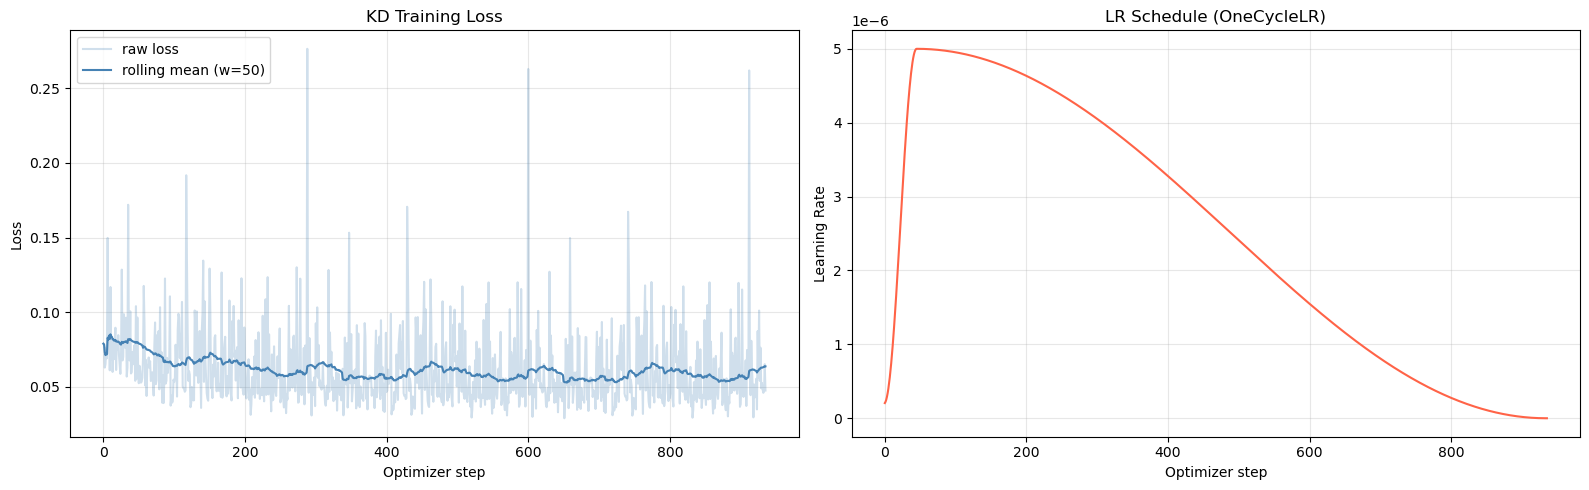

In [34]:
RUN_DISTILLATION = True

if RUN_DISTILLATION:
    force_full_cleanup()    
    
    gsm8k   = load_dataset("openai/gsm8k", "main", split="train").select(range(3000))
    alpaca  = load_dataset("tatsu-lab/alpaca", split="train").select(range(2000))

    def normalize_gsm8k(example):
        return {
            "prompt"  : format_prompt(example["question"]),
            "response": example["answer"] + tokenizer.eos_token,
        }

    def normalize_alpaca(example):
        question = (
            f"{example['instruction']}\n{example['input']}"
            if example["input"].strip()
            else example["instruction"]
        )
        return {
            "prompt"  : format_prompt(question),
            "response": example["output"] + tokenizer.eos_token,
        }

    gsm8k_norm  = gsm8k.map(normalize_gsm8k,  remove_columns=gsm8k.column_names)
    alpaca_norm = alpaca.map(normalize_alpaca, remove_columns=alpaca.column_names)

    mixed = concatenate_datasets([gsm8k_norm, alpaca_norm])
    mixed = mixed.shuffle(seed=SEED)

    def encode(example):
        prompt     = example["prompt"]
        full       = prompt + example["response"]

        enc        = tokenizer(full, truncation=True, max_length=MAX_LENGTH)
        input_ids  = enc["input_ids"]
        attn_mask  = enc["attention_mask"]

        # mask the prompt tokens so loss is computed only on the response
        prompt_len = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])
        labels     = [-100] * prompt_len + input_ids[prompt_len:]
        labels     = labels[:len(input_ids)]

        return {
            "input_ids"     : input_ids,
            "attention_mask": attn_mask,
            "labels"        : labels,
        }

    tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_ID, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    dataset = mixed.map(encode, remove_columns=mixed.column_names)
    dataset.set_format(type="torch")

    print(f"Total training examples : {len(dataset)}")
    print(f"  GSM8K                 : 3000")
    print(f"  Alpaca                : 2000")

    # Teacher (frozen)
    teacher = AutoModelForCausalLM.from_pretrained(
        TEACHER_MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto")
    teacher.eval()
    check_vram("TEACHER model loaded")
    
    for p in teacher.parameters():
        p.requires_grad = False

    # Student (trainable)
    student = AutoModelForCausalLM.from_pretrained(
        STUDENT_MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto")
    student.train()
    check_vram("STUDENT model loaded")

    optimizer  = AdamW(student.parameters(), lr=DISTILL_LR)
    
    total_steps = (DISTILL_SAMPLES // GRAD_ACCUM_STEPS) * DISTILL_EPOCHS
    scheduler   = OneCycleLR(
        optimizer,
        max_lr       = DISTILL_LR,
        total_steps  = total_steps,
        pct_start    = 0.05,     # 5% warmup
        anneal_strategy = "cos",
    )
    
    loss_log = []
    lr_log   = []
    step = 0
    
    for epoch in range(DISTILL_EPOCHS):
        for i, batch in enumerate(tqdm(dataset)):
    
            input_ids = batch["input_ids"].unsqueeze(0).to(device)
            attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
            labels = batch["labels"].unsqueeze(0).to(device)
    
            with torch.no_grad():
                t_out = teacher(input_ids=input_ids, attention_mask=attention_mask)
    
            s_out = student(input_ids=input_ids, attention_mask=attention_mask)
    
            t_logits = t_out.logits[:, :-1, :]
            s_logits = s_out.logits[:, :-1, :]
            labels_shift = labels[:, 1:]
    
            mask = labels_shift != -100
    
            kd = distillation_loss(s_logits, t_logits, mask, TEMPERATURE)
            ce = ce_loss(s_logits, labels_shift)
    
            loss = KD_ALPHA * kd + (1 - KD_ALPHA) * ce
            loss = loss / GRAD_ACCUM_STEPS
    
            loss.backward()
    
            if (i + 1) % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(student.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                lr_log.append(scheduler.get_last_lr()[0])
                optimizer.zero_grad()
                step += 1
                loss_log.append(loss.item())
    
            if i % 200 == 0:
                print(f"epoch={epoch} step={i} loss={loss.item():.4f}")

    DISTILLED_PATH = ROOT_DIR + "/distilled_student"
    student.save_pretrained(DISTILLED_PATH)
    tokenizer.save_pretrained(DISTILLED_PATH)
    print(f"\nDistilled model saved to {DISTILLED_PATH}")
    
    teacher = free_model(teacher)
    student = free_model(student)

    # Loss and Lr curves
    if loss_log:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
        window = 50
        smooth = pd.Series(loss_log).rolling(window, min_periods=1).mean()
        axes[0].plot(loss_log, alpha=0.25, color="steelblue", label="raw loss")
        axes[0].plot(smooth,   color="steelblue", label=f"rolling mean (w={window})")
        axes[0].set_xlabel("Optimizer step")
        axes[0].set_ylabel("Loss")
        axes[0].set_title("KD Training Loss")
        axes[0].legend()
        axes[0].grid(alpha=0.3)
    
        # LR schedule trace
        axes[1].plot(lr_log, color="tomato")
        axes[1].set_title("LR Schedule (OneCycleLR)")
        axes[1].set_xlabel("Optimizer step")
        axes[1].set_ylabel("Learning Rate")
        axes[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
        axes[1].grid(alpha=0.3)
    
        plt.tight_layout()
        plt.savefig(ROOT_DIR + "/distillation_loss.png", dpi=150)
        plt.show()

In [35]:
try:
    force_full_cleanup()
    reset_vram_peak()
    model_distilled = AutoModelForCausalLM.from_pretrained(
        DISTILLED_PATH, torch_dtype=torch.bfloat16, device_map="auto")
    model_distilled.eval()
    check_vram("Destilled model loaded")

    tp   = measure_throughput(model_distilled, tokenizer, PROMPT)
    ppl  = compute_perplexity(model_distilled, tokenizer)
    acc  = evaluate_gsm8k(model_distilled, tokenizer)
    tqa  = evaluate_triviaqa(model_distilled, tokenizer)
    vram = get_vram_gb()
    sz   = model_size_gb(model_distilled)

    log_result("1B Instruct (distilled)", vram, sz, tp, ppl, acc, tqa)
    model_distilled = free_model(model_distilled)

except Exception as e:
    print(f"Distilled model not found — {e}")
    print("Run the distillation training cell first.")

[after cleanup] VRAM — alloc: 11.47 GB | reserved: 11.81 GB | free: 39.46 GB / 50.9 GB total
[Destilled model loaded] VRAM — alloc: 13.94 GB | reserved: 14.03 GB | free: 36.99 GB / 50.9 GB total


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  TTFT std (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
              BF16 (baseline)       8.25       6.43       76.27      14.00           0.03      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       31.11      52.19           0.37      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       58.34      26.01           0.08      10.534       67.0          43.0
                    AWQ 4-bit       8.52       6.69       78.05      13.99           0.02      20.449       62.0          40.0
                  BF16 + SDPA       8.25       6.43       77.22      14.10           0.01      10.010       67.0          54.0
                   BF16 + FA2       8.25       6.43       60.73      17.50           0.09      10.008       67.0          52.0
         BF16 + torch.compile      31.24       6.43       77.48      14.08           0.03      10.010       67.

## 8. Systems Profiling (KV Cache Optimization & Batching)

This section focuses on *runtime behavior* of transformer inference on CUDA GPUs. The goal is to characterize how architectural and execution-level factors affect throughput, latency, and memory efficiency.

Profiling is performed using `torch.profiler`, CUDA timing utilities, and VRAM monitoring.

---

### 8.1 Objectives

We evaluate four system-level dimensions:

1. **Throughput scaling with batch size**
   - Relationship between batch size and tokens/sec
   - GPU utilization and saturation behavior

2. **KV cache memory growth**
   - Linear scaling with sequence length
   - Impact on maximum context length and VRAM limits

3. **Memory bandwidth utilization**
   - Achieved bandwidth vs theoretical GPU peak
   - Identification of memory-bound vs compute-bound regimes

4. **Kernel-level profiling**
   - CUDA execution traces via `torch.profiler`
   - Chrome trace export for visualization and debugging

---

### 8.2 KV Cache Behavior

The KV cache stores intermediate attention states during autoregressive decoding to avoid recomputation.

Key properties:
- Grows linearly with sequence length
- Stored per transformer layer
- Typically the dominant source of VRAM usage during inference

This makes KV cache management a primary constraint in long-context generation.

---

### 8.3 Batch Size vs Throughput

Batch size affects GPU performance through a trade-off:

- **Small batch sizes**
  - Underutilized GPU
  - Lower throughput
  - Minimal memory pressure

- **Moderate batch sizes**
  - Better hardware utilization
  - Peak throughput region

- **Large batch sizes**
  - Increased VRAM usage (KV cache duplication)
  - Higher latency per request
  - Risk of memory saturation

The optimal batch size is typically at the point of maximum GPU utilization before memory constraints dominate.

---

### 8.4 Memory Bandwidth Analysis

We measure how efficiently kernels use GPU memory bandwidth.

Typical regimes:
- **Compute-bound:** limited by arithmetic throughput
- **Memory-bound:** limited by global memory access patterns (common in attention layers)
- **Balanced:** ideal operating region for optimized kernels

Long-sequence inference often shifts workloads toward memory-bound behavior.

---

### 8.5 Profiling with `torch.profiler`

We use PyTorch’s profiler to inspect both CPU and GPU execution.

Captured signals include:
- CUDA kernel execution timing
- Memory allocation events
- CPU dispatch overhead
- Synchronization delays

Outputs are exported in Chrome tracing format for interactive inspection.

---

### 8.6 Practical Insights

Profiling typically reveals the following optimization opportunities:

- Increasing batch size improves throughput until VRAM saturation
- KV cache is the primary memory bottleneck in long-context inference
- Attention kernels dominate runtime in sequence-heavy workloads
- Kernel fusion and optimized attention implementations reduce overhead significantly

---


In [36]:
# Load best quantised model for profiling
force_full_cleanup()
reset_vram_peak()
model_profile = AutoModelForCausalLM.from_pretrained(MODEL_ID, **NF4_KWARGS)
model_profile.eval()
check_vram("profiling model loaded")

[after cleanup] VRAM — alloc: 11.47 GB | reserved: 11.81 GB | free: 39.46 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[profiling model loaded] VRAM — alloc: 13.71 GB | reserved: 14.89 GB | free: 37.22 GB / 50.9 GB total


In [37]:
import numpy as np

PEAK_BANDWIDTH_GBPS = {
    "NVIDIA T4": 320,
    "NVIDIA A100-SXM4-80GB": 2039,
    "NVIDIA A100-SXM4-40GB": 1555,
    "NVIDIA A100 80GB PCIe": 1935,
    "NVIDIA RTX A6000": 768,
    "NVIDIA H100": 3350,
}
PEAK_FP16_TFLOPS = {
    "NVIDIA T4": 65,
    "NVIDIA A100-SXM4-80GB": 312,
    "NVIDIA A100-SXM4-40GB": 312,
    "NVIDIA A100 80GB PCIe": 312,
    "NVIDIA RTX A6000": 309,
    "NVIDIA H100": 989,
}

def get_hardware_specs():
    """Returns (name, peak_bandwidth_GB/s, peak_fp16_TFLOPS). Warns instead
    of silently guessing if the GPU isn't in the table."""
    name = torch.cuda.get_device_name(0)
    for key in PEAK_BANDWIDTH_GBPS:
        if key.lower() in name.lower() or name.lower() in key.lower():
            return name, PEAK_BANDWIDTH_GBPS[key], PEAK_FP16_TFLOPS[key]
    print(f"[ERROR] '{name}' not in the hardware spec table — falling back to "
          f"A6000-level numbers. Add your GPU to PEAK_BANDWIDTH_GBPS / "
          f"PEAK_FP16_TFLOPS above for an accurate roofline.")
    return name, 768, 309

def theoretical_kv_cache_bytes(model, seq_len: int, batch_size: int = 1,
                               dtype_bytes: int = 2) -> float:
    """KV cache size in bytes, computed from the model's own config —
    correct for any architecture, not hardcoded to one model's dims."""
    cfg        = model.config
    n_layers   = cfg.num_hidden_layers
    n_kv_heads = getattr(cfg, "num_key_value_heads", cfg.num_attention_heads)
    head_dim   = cfg.hidden_size // cfg.num_attention_heads
    return 2 * n_layers * n_kv_heads * head_dim * seq_len * batch_size * dtype_bytes

def get_kv_cache_bytes(past_key_values) -> int:
    """Handles both the legacy tuple-of-tuples format and the newer
    DynamicCache object (transformers >= 4.36)."""
    total = 0
    if hasattr(past_key_values, "key_cache"):
        for k, v in zip(past_key_values.key_cache, past_key_values.value_cache):
            total += k.element_size() * k.numel() + v.element_size() * v.numel()
    else:
        for k, v in past_key_values:
            total += k.element_size() * k.numel() + v.element_size() * v.numel()
    return total

print("Helpers loaded.")

Helpers loaded.


In [38]:
VARIANTS = {"BF16": BF16_KWARGS, "INT8": INT8_KWARGS, "NF4": NF4_KWARGS}

BATCH_SIZES    = [1, 2, 4, 8, 16, 32]
N_TRIALS_BATCH = 3
tokenizer.padding_side = "left"

batch_scaling_results = {}

for variant_name, kwargs in VARIANTS.items():
    print(f"\n{'='*60}\nBatch scaling — {variant_name}\n{'='*60}")
    reset_vram_peak()
    
    m = AutoModelForCausalLM.from_pretrained(MODEL_ID, **kwargs)
    m.eval()
    dev = next(m.parameters()).device

    rows = []
    for bs in BATCH_SIZES:
        try:
            inputs = tokenizer([format_prompt(PROMPT)] * bs, return_tensors="pt",
                               padding=True, truncation=True).to(dev)
            with torch.no_grad():
                _ = m.generate(**inputs, max_new_tokens=5, pad_token_id=tokenizer.eos_token_id)
            torch.cuda.synchronize()

            tps, vram, lat = [], [], []
            for _ in range(N_TRIALS_BATCH):
                reset_vram_peak()
                torch.cuda.synchronize()
                t0 = time.perf_counter()
                with torch.no_grad():
                    out = m.generate(**inputs, max_new_tokens=50, do_sample=False,
                                     pad_token_id=tokenizer.eos_token_id)
                torch.cuda.synchronize()
                elapsed = time.perf_counter() - t0
                tokens_gen = (out.shape[1] - inputs["input_ids"].shape[1]) * bs
                tps.append(tokens_gen / elapsed); vram.append(get_vram_gb()); lat.append(elapsed)

            rows.append({
                "Batch Size": bs,
                "Tok/sec (mean)": round(float(np.mean(tps)), 1),
                "Tok/sec (std)" : round(float(np.std(tps)), 1),
                "VRAM (GB)"     : round(float(np.mean(vram)), 2),
                "Latency (s)"   : round(float(np.mean(lat)), 2),
            })
            print(f"  bs={bs:3d} | {np.mean(tps):7.1f} ± {np.std(tps):4.1f} tok/s | {np.mean(vram):.2f} GB")
        except torch.cuda.OutOfMemoryError:
            print(f"  bs={bs}: OOM — stopping")
            torch.cuda.empty_cache()
            break

    batch_scaling_results[variant_name] = pd.DataFrame(rows)
    m = free_model(m)
    check_vram(f"after {variant_name}")

print("\nDone.")


Batch scaling — BF16


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  bs=  1 |    75.9 ±  0.2 tok/s | 20.15 GB
  bs=  2 |   148.0 ±  0.8 tok/s | 20.16 GB
  bs=  4 |   290.6 ±  0.2 tok/s | 20.18 GB
  bs=  8 |   570.0 ±  0.3 tok/s | 20.22 GB
  bs= 16 |  1072.2 ±  0.1 tok/s | 20.31 GB
  bs= 32 |  1902.5 ±  1.2 tok/s | 20.48 GB
[after BF16] VRAM — alloc: 13.71 GB | reserved: 13.82 GB | free: 37.21 GB / 50.9 GB total

Batch scaling — INT8


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  bs=  1 |    31.2 ±  0.2 tok/s | 17.33 GB
  bs=  2 |    54.8 ±  0.3 tok/s | 17.34 GB
  bs=  4 |   108.6 ±  0.3 tok/s | 17.37 GB
  bs=  8 |   211.5 ±  0.3 tok/s | 17.41 GB
  bs= 16 |   398.8 ±  0.0 tok/s | 17.49 GB
  bs= 32 |   797.4 ±  1.5 tok/s | 17.67 GB
[after INT8] VRAM — alloc: 13.71 GB | reserved: 16.66 GB | free: 37.21 GB / 50.9 GB total

Batch scaling — NF4


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  bs=  1 |    58.6 ±  0.2 tok/s | 16.01 GB
  bs=  2 |    77.5 ±  0.1 tok/s | 16.03 GB
  bs=  4 |   153.5 ±  0.2 tok/s | 16.05 GB
  bs=  8 |   304.2 ±  0.2 tok/s | 16.09 GB
  bs= 16 |   587.6 ±  0.3 tok/s | 16.17 GB
  bs= 32 |  1109.4 ±  0.7 tok/s | 16.33 GB
[after NF4] VRAM — alloc: 13.71 GB | reserved: 13.83 GB | free: 37.21 GB / 50.9 GB total

Done.


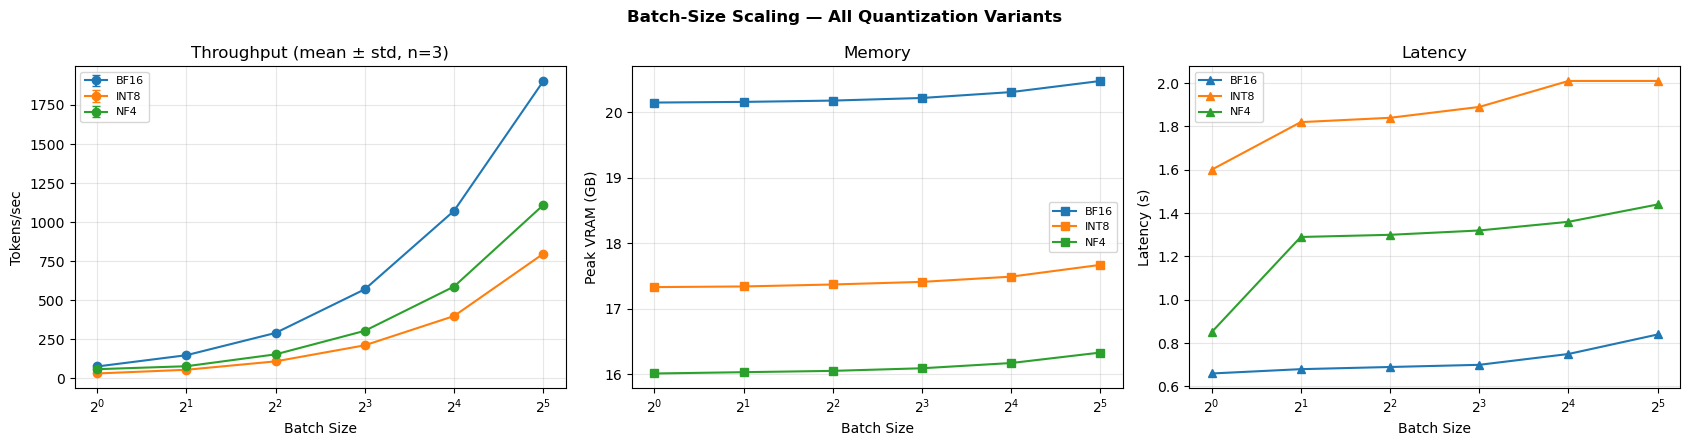

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle("Batch-Size Scaling — All Quantization Variants", fontweight="bold")
palette = sns.color_palette("tab10", n_colors=len(batch_scaling_results))
colors  = {name: palette[i] for i, name in enumerate(batch_scaling_results)}

for name, df_ in batch_scaling_results.items():
    if df_.empty: continue
    c = colors[name]
    axes[0].errorbar(df_["Batch Size"], df_["Tok/sec (mean)"], yerr=df_["Tok/sec (std)"],
                     marker="o", label=name, color=c, capsize=3)
    axes[1].plot(df_["Batch Size"], df_["VRAM (GB)"], marker="s", label=name, color=c)
    axes[2].plot(df_["Batch Size"], df_["Latency (s)"], marker="^", label=name, color=c)

axes[0].set(xlabel="Batch Size", ylabel="Tokens/sec", title="Throughput (mean ± std, n=3)")
axes[1].set(xlabel="Batch Size", ylabel="Peak VRAM (GB)", title="Memory")
axes[2].set(xlabel="Batch Size", ylabel="Latency (s)", title="Latency")
for ax in axes:
    ax.set_xscale("log", base=2); ax.grid(alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT_DIR + "/batch_scaling_multivariant.png", dpi=150, bbox_inches="tight")
plt.show()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[KV-cache model loaded] VRAM — alloc: 15.17 GB | reserved: 17.83 GB | free: 35.76 GB / 50.9 GB total
  seq=   64 | measured     7.34 MB | theoretical     7.34 MB
  seq=  128 | measured    14.68 MB | theoretical    14.68 MB
  seq=  256 | measured    29.36 MB | theoretical    29.36 MB
  seq=  512 | measured    58.72 MB | theoretical    58.72 MB
  seq= 1024 | measured   117.44 MB | theoretical   117.44 MB
  seq= 2048 | measured   234.88 MB | theoretical   234.88 MB
  seq= 4096 | measured   469.76 MB | theoretical   469.76 MB

  Seq Length  Measured KV (MB)  Theoretical KV (MB)
         64              7.34                 7.34
        128             14.68                14.68
        256             29.36                29.36
        512             58.72                58.72
       1024            117.44               117.44
       2048            234.88               234.88
       4096            469.76               469.76


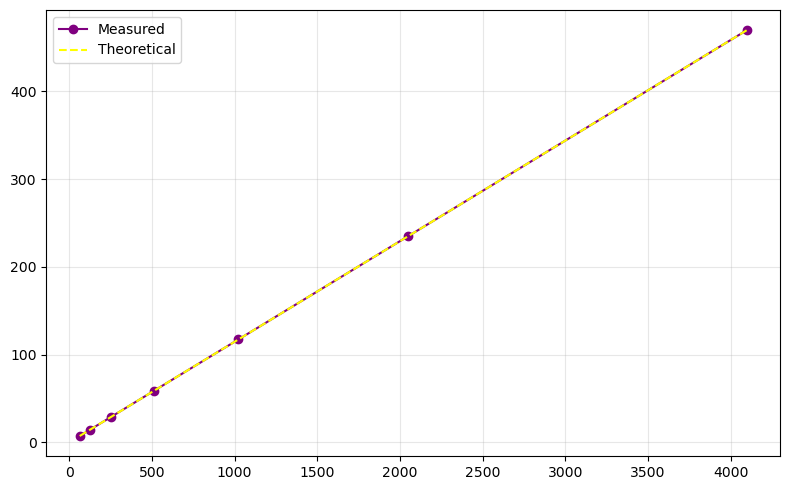

In [40]:
reset_vram_peak()
model_profile = AutoModelForCausalLM.from_pretrained(MODEL_ID, **NF4_KWARGS)
model_profile.eval()
dev = next(model_profile.parameters()).device
check_vram("KV-cache model loaded")

SEQ_LENGTHS = [64, 128, 256, 512, 1024, 2048, 4096]
kv_rows = []

for seq_len in SEQ_LENGTHS:
    try:
        dummy = torch.randint(0, tokenizer.vocab_size, (1, seq_len)).to(dev)
        with torch.no_grad():
            out = model_profile(dummy, use_cache=True)

        measured     = get_kv_cache_bytes(out.past_key_values)
        theoretical  = theoretical_kv_cache_bytes(model_profile, seq_len, dtype_bytes=2)

        kv_rows.append({
            "Seq Length": seq_len,
            "Measured KV (MB)": round(measured / 1e6, 2),
            "Theoretical KV (MB)": round(theoretical / 1e6, 2),
        })
        print(f"  seq={seq_len:5d} | measured {measured/1e6:8.2f} MB | theoretical {theoretical/1e6:8.2f} MB")
        del out; torch.cuda.empty_cache()
    except torch.cuda.OutOfMemoryError:
        print(f"  seq={seq_len}: OOM — stopping"); break

df_kv = pd.DataFrame(kv_rows)
print("\n", df_kv.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(df_kv["Seq Length"], df_kv["Measured KV (MB)"], "o-", label="Measured", color="purple")
plt.plot(df_kv["Seq Length"], df_kv["Theoretical KV (MB)"], "--", label="Theoretical", color="yellow")
plt.xlabel="Sequence Length"
plt.ylabel="KV Cache (MB)"
plt.title="Measured vs Theoretical"
plt.legend() 
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT_DIR + "/kv_cache_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

model_profile = free_model(model_profile)

Reference params: 3.215 B
NVIDIA RTX A6000: 309 TFLOPS, 768 GB/s, ridge=402.3 FLOPs/byte


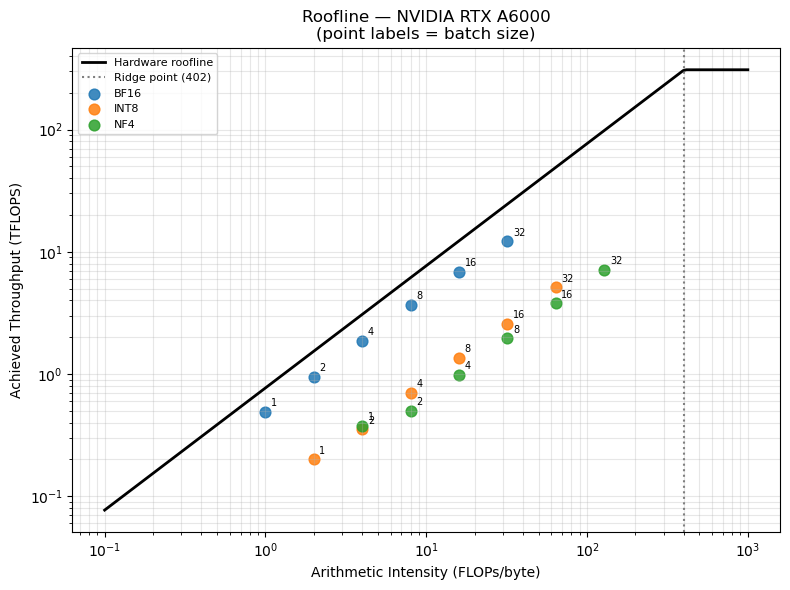

Variant  Batch Size  AI (FLOPs/byte)  Achieved (TFLOPS)
   BF16         1.0              1.0           0.488037
   BF16         2.0              2.0           0.951640
   BF16         4.0              4.0           1.868558
   BF16         8.0              8.0           3.665100
   BF16        16.0             16.0           6.894246
   BF16        32.0             32.0          12.233075
   INT8         1.0              2.0           0.200616
   INT8         2.0              4.0           0.352364
   INT8         4.0              8.0           0.698298
   INT8         8.0             16.0           1.359945
   INT8        16.0             32.0           2.564284
   INT8        32.0             64.0           5.127282
    NF4         1.0              4.0           0.376798
    NF4         2.0              8.0           0.498325
    NF4         4.0             16.0           0.987005
    NF4         8.0             32.0           1.956006
    NF4        16.0             64.0           3

In [41]:
# Requires the BF16 baseline stage to have already run, to get param count.
REFERENCE_N_PARAMS = None
for r in RESULTS:
    if r["Label"] == "BF16 (baseline)":
        REFERENCE_N_PARAMS = int(r["Size (GB)"] * 1e9 / 2)
        break
assert REFERENCE_N_PARAMS, "Run the BF16 baseline stage first."
print(f"Reference params: {REFERENCE_N_PARAMS/1e9:.3f} B")

device_name, peak_bw_gbs, peak_flops_tflops = get_hardware_specs()
peak_flops  = peak_flops_tflops * 1e12
peak_bw     = peak_bw_gbs * 1e9
ridge_point = peak_flops / peak_bw
print(f"{device_name}: {peak_flops_tflops:.0f} TFLOPS, {peak_bw_gbs:.0f} GB/s, ridge={ridge_point:.1f} FLOPs/byte")

BYTES_PER_PARAM = {"BF16": 2, "INT8": 1, "NF4": 0.5, "GPTQ": 0.5}
roofline_points = []

for variant_name, df_ in batch_scaling_results.items():
    if df_.empty: continue
    param_bytes = REFERENCE_N_PARAMS * BYTES_PER_PARAM.get(variant_name, 2)
    for _, row in df_.iterrows():
        bs            = row["Batch Size"]
        tok_s         = row["Tok/sec (mean)"]
        time_per_step = bs / tok_s
        # Approximation: forward-pass FLOPs/token ≈ 2 × N_params (standard estimate)
        flops_per_step   = 2 * REFERENCE_N_PARAMS * bs
        achieved_flops_s = flops_per_step / time_per_step
        # Weights are read once per step and reused across the batch —
        # this is exactly why arithmetic intensity scales with batch size.
        ai = flops_per_step / param_bytes
        roofline_points.append({"Variant": variant_name, "Batch Size": bs,
                                "AI (FLOPs/byte)": ai,
                                "Achieved (TFLOPS)": achieved_flops_s / 1e12})

df_roof = pd.DataFrame(roofline_points)

fig, ax = plt.subplots(figsize=(8, 6))
ai_range = np.logspace(-1, 3, 200)
roof = np.minimum(ai_range * (peak_bw / 1e12), peak_flops_tflops)
ax.plot(ai_range, roof, color="black", linewidth=2, label="Hardware roofline")
ax.axvline(ridge_point, color="gray", linestyle=":", label=f"Ridge point ({ridge_point:.0f})")

for variant_name in df_roof["Variant"].unique():
    sub = df_roof[df_roof["Variant"] == variant_name]
    ax.scatter(sub["AI (FLOPs/byte)"], sub["Achieved (TFLOPS)"], label=variant_name, s=60, alpha=0.85)
    for _, r in sub.iterrows():
        ax.annotate(str(int(r["Batch Size"])), (r["AI (FLOPs/byte)"], r["Achieved (TFLOPS)"]),
                    fontsize=7, textcoords="offset points", xytext=(4, 4))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set(xlabel="Arithmetic Intensity (FLOPs/byte)", ylabel="Achieved Throughput (TFLOPS)",
      title=f"Roofline — {device_name}\n(point labels = batch size)")
ax.legend(fontsize=8)

ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(ROOT_DIR + "/roofline_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_roof.to_string(index=False))

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  --------------------------------------------------------------------------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls                                                                      Input Shapes  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  -------------------------------------------------------------------------

,Operation,CUDA Time (ms),CPU Time (ms),CUDA Memory (MB),Calls
0,model_inference,1495.313870,0.000000,0.000000,1
1,model_inference,446.057663,1518.524270,0.000000,1
2,bitsandbytes::gemv_4bit,184.819562,165.441605,75.866112,9604
3,"void kgemm_4bit_inference_naive<__half, 128, 1...",184.819562,0.000000,0.000000,9604
4,aten::matmul,62.151849,8.012165,65.501184,296
5,aten::linear,62.066412,6.877928,65.467392,246
6,aten::mm,62.066412,4.718277,65.467392,246
7,"void gemv2T_kernel_val<int, int, __half, __hal...",52.876074,0.000000,0.000000,50
8,aten::add,38.773857,131.509298,8680.983552,18154
9,"void kDequantizeBlockwise<float, 512, 64, 8, 0...",31.205971,0.000000,0.000000,9800


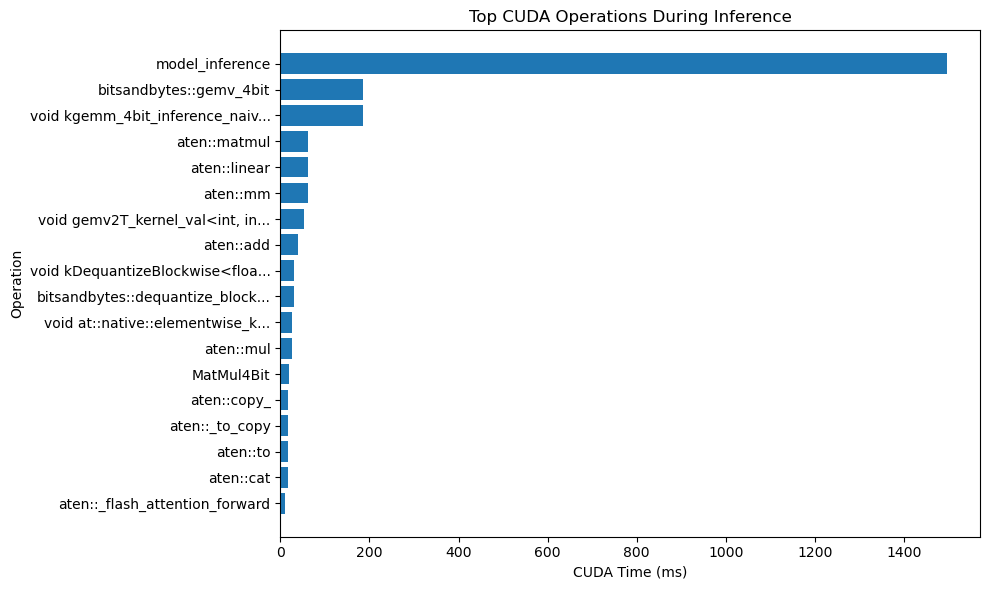

Saved to: outputs/cuda_profile_summary.csv


In [42]:
from torch.profiler import profile, record_function, ProfilerActivity
import importlib
importlib.reload(plt)

RUN_PROFILER = True
if RUN_PROFILER:
    reset_vram_peak()

    model_profile = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        **NF4_KWARGS
    )
    model_profile.eval()

    device = next(model_profile.parameters()).device

    inputs = tokenizer(format_prompt(PROMPT), return_tensors="pt").to(device)

    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True,
        profile_memory=True,
        with_stack=False
    ) as prof:
        with record_function("model_inference"):
            with torch.no_grad():
                model_profile.generate(
                    **inputs,
                    max_new_tokens=50,
                    pad_token_id=tokenizer.eos_token_id
                )

    # 1. Raw table from PyTorch profiler
    print(
        prof.key_averages(
            group_by_input_shape=True
        ).table(
            sort_by="cuda_time_total",
            row_limit=30
        )
    )

    # 2. DataFrame 
    # To print all the methods use:
    #    event = next(iter(prof.key_averages())); print(dir(event))
    rows = []
    for evt in prof.key_averages():
        rows.append({
            "Operation": evt.key,
            "CUDA Time (ms)": evt.device_time_total / 1000.0,
            "CPU Time (ms)": evt.cpu_time_total / 1000.0,
            "CUDA Memory (MB)": evt.device_memory_usage / 1e6,
            "Calls": evt.count
        })

    df_prof = (
        pd.DataFrame(rows)
        .sort_values("CUDA Time (ms)", ascending=False)
        .reset_index(drop=True)
    )
    
    # Displaying 20 most often operations
    display(df_prof.head(20))
    
    # 3. Top operations from CUDA as a plot
    top_20 = df_prof.head(20)
    
    # Cutting the labels
    labels = top_20["Operation"].astype(str).apply(lambda x: x if len(x) <= 30 else x[:30] + "...")
    
    plt.figure(figsize=(10, 6))
    plt.barh(labels, top_20["CUDA Time (ms)"])
    plt.gca().invert_yaxis() 
    
    plt.xlabel("CUDA Time (ms)")
    plt.ylabel("Operation")
    plt.title("Top CUDA Operations During Inference")
    plt.tight_layout()
    plt.show()
    
    # 4. Saving to file
    CUDA_PROFILE_PATH = ROOT_DIR + "/cuda_profile_summary.csv"
    df_prof.to_csv(CUDA_PROFILE_PATH, index=False)
    print(f"Saved to: {CUDA_PROFILE_PATH}")
    
    model_profile = free_model(model_profile)
    torch.cuda.empty_cache()

---
## 9. Results — tradeoff analysis & efficiency frontier

All metrics normalised relative to the BF16 baseline.


In [43]:
# Full results table with delta columns
df = pd.DataFrame(RESULTS)

# Guard: drop rows where baseline was not logged yet
if "BF16 (baseline)" in df["Label"].values:
    base_row = df[df["Label"] == "BF16 (baseline)"].iloc[0]

    df["PPL Δ (%)"]       = ((df["Perplexity"] - base_row["Perplexity"])
                              / base_row["Perplexity"] * 100).round(1)
    df["Speed Δ (%)"]     = ((df["Tokens/sec"] - base_row["Tokens/sec"])
                              / base_row["Tokens/sec"] * 100).round(1)
    df["VRAM saved (%)"]  = ((base_row["VRAM (GB)"] - df["VRAM (GB)"])
                              / base_row["VRAM (GB)"] * 100).round(1)
    df["Eff. Score"]      = (df["Tokens/sec"] / df["VRAM (GB)"]).round(1)

display(df)

,Label,VRAM (GB),Size (GB),Tokens/sec,TTFT (ms),TTFT std (ms),Perplexity,GSM8K (%),TriviaQA (%),PPL Δ (%),Speed Δ (%),VRAM saved (%),Eff. Score
0,BF16 (baseline),8.25,6.43,76.27,14.00,0.03,10.010,67.0,54.0,0.0,0.0,0.0,9.2
1,INT8 (bnb),5.44,3.61,31.11,52.19,0.37,10.020,57.0,54.0,0.1,-59.2,34.1,5.7
2,NF4 4-bit (bnb),6.89,2.20,58.34,26.01,0.08,10.534,67.0,43.0,5.2,-23.5,16.5,8.5
3,AWQ 4-bit,8.52,6.69,78.05,13.99,0.02,20.449,62.0,40.0,104.3,2.3,-3.3,9.2
4,BF16 + SDPA,8.25,6.43,77.22,14.10,0.01,10.010,67.0,54.0,0.0,1.2,0.0,9.4
5,BF16 + FA2,8.25,6.43,60.73,17.50,0.09,10.008,67.0,52.0,-0.0,-20.4,0.0,7.4
6,BF16 + torch.compile,31.24,6.43,77.48,14.08,0.03,10.010,67.0,54.0,0.0,1.6,-278.7,2.5
7,Pruned 20 % (L1 unstructured),34.66,6.43,77.07,14.18,0.03,10.884,50.0,54.0,8.7,1.0,-320.1,2.2
8,Pruned 40 % (L1 unstructured),37.65,6.43,77.02,14.19,0.02,22.471,26.0,26.0,124.5,1.0,-356.4,2.0
9,1B Instruct (no distill),15.72,2.47,173.66,6.48,0.01,11.724,46.0,28.0,17.1,127.7,-90.5,11.0


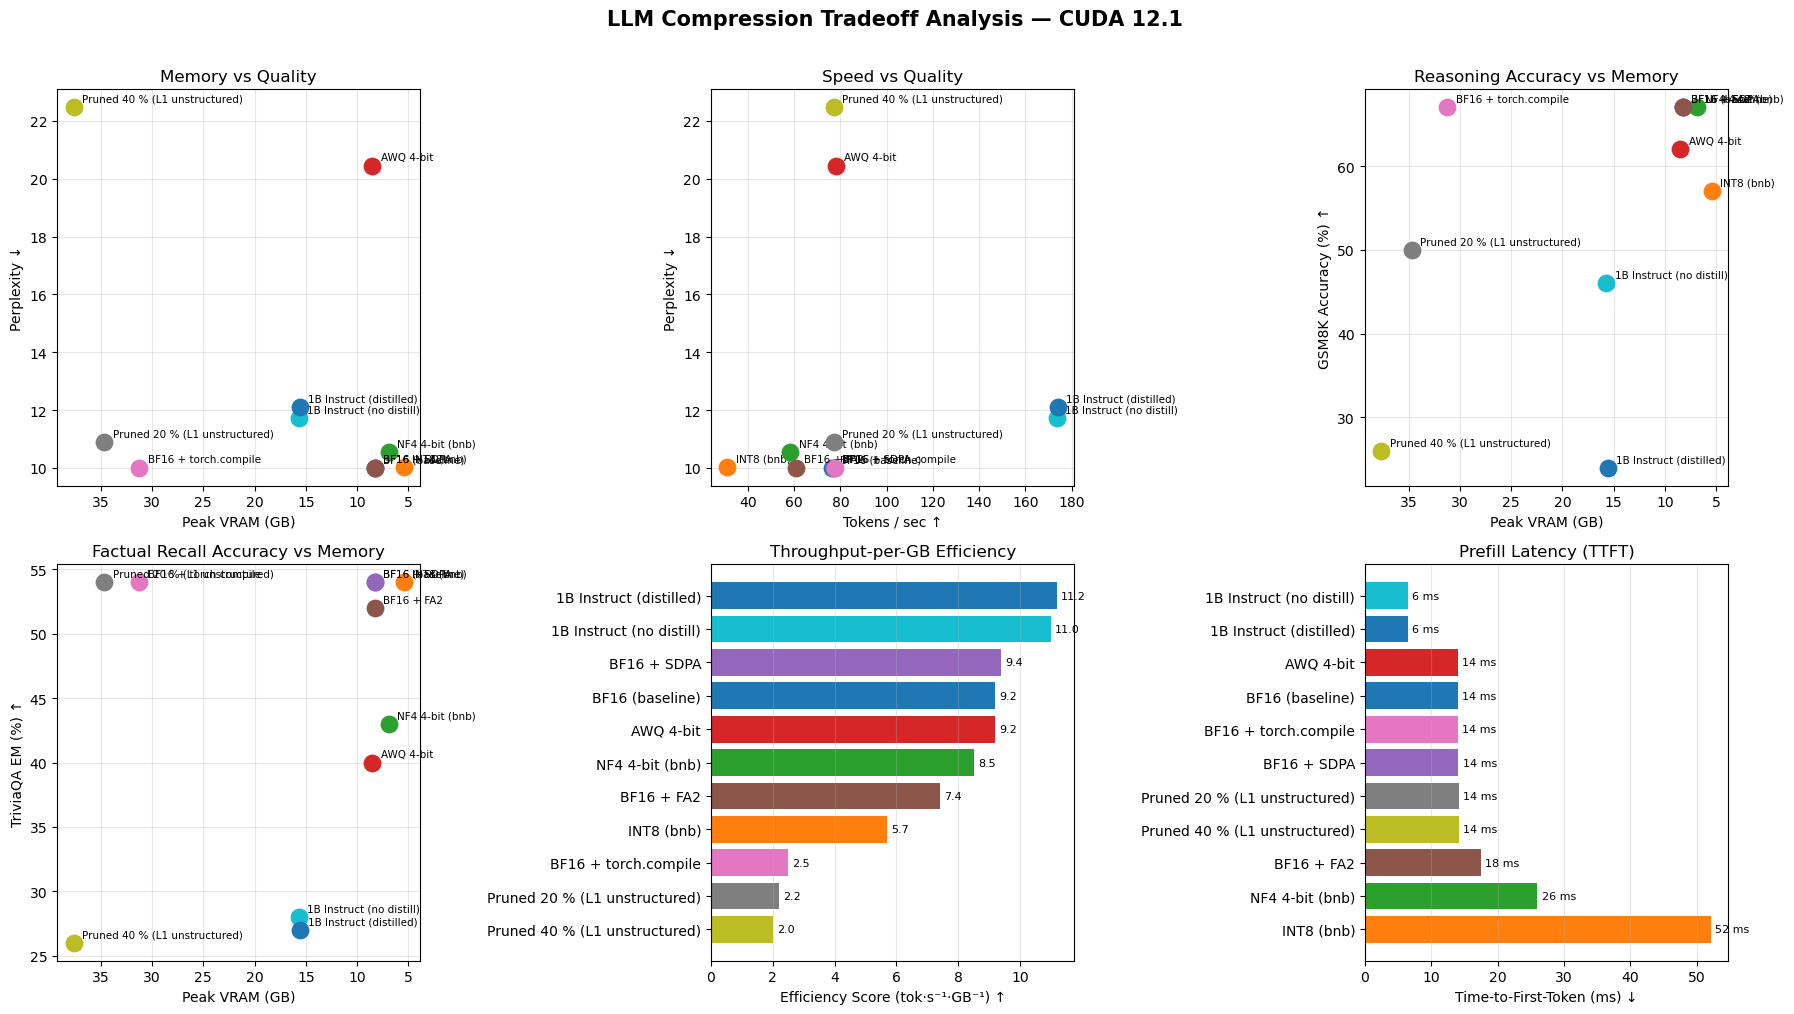

Saved to: outputs/tradeoff_analysis.png


In [44]:
# Comprehensive tradeoff plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LLM Compression Tradeoff Analysis — CUDA 12.1",
             fontsize=15, fontweight="bold", y=1.01)

palette = sns.color_palette("tab10", n_colors=len(df))
colors  = {row["Label"]: palette[i] for i, (_, row) in enumerate(df.iterrows())}

def scatter_annotate(ax, x_col, y_col):
    for _, row in df.iterrows():
        if pd.isna(row[x_col]) or pd.isna(row[y_col]):
            continue
        ax.scatter(row[x_col], row[y_col], s=140,
                   color=colors[row["Label"]], zorder=3)
        ax.annotate(row["Label"], (row[x_col], row[y_col]),
                    textcoords="offset points", xytext=(6, 4), fontsize=7.5)
    ax.grid(alpha=0.3)

# 1. Perplexity vs VRAM
ax = axes[0, 0]
scatter_annotate(ax, "VRAM (GB)", "Perplexity")
ax.set_xlabel("Peak VRAM (GB)"); ax.set_ylabel("Perplexity ↓")
ax.set_title("Memory vs Quality")
ax.invert_xaxis()

# 2. Tokens/sec vs Perplexity
ax = axes[0, 1]
scatter_annotate(ax, "Tokens/sec", "Perplexity")
ax.set_xlabel("Tokens / sec ↑"); ax.set_ylabel("Perplexity ↓")
ax.set_title("Speed vs Quality")

# 3. GSM8K Accuracy vs VRAM
ax = axes[0, 2]
df_acc = df.dropna(subset=["GSM8K (%)"])
for _, row in df_acc.iterrows():
    ax.scatter(row["VRAM (GB)"], row["GSM8K (%)"], s=140,
               color=colors[row["Label"]], zorder=3)
    ax.annotate(row["Label"], (row["VRAM (GB)"], row["GSM8K (%)"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax.set_xlabel("Peak VRAM (GB)"); ax.set_ylabel("GSM8K Accuracy (%) ↑")
ax.set_title("Reasoning Accuracy vs Memory")
ax.invert_xaxis()
ax.grid(alpha=0.3)

# 4. TriviaQA Accuracy vs VRAM
ax = axes[1, 0]
df_tqa = df.dropna(subset=["TriviaQA (%)"])
for _, row in df_tqa.iterrows():
    ax.scatter(row["VRAM (GB)"], row["TriviaQA (%)"], s=140,
               color=colors[row["Label"]], zorder=3)
    ax.annotate(row["Label"], (row["VRAM (GB)"], row["TriviaQA (%)"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax.set_xlabel("Peak VRAM (GB)"); ax.set_ylabel("TriviaQA EM (%) ↑")
ax.set_title("Factual Recall Accuracy vs Memory")
ax.invert_xaxis()
ax.grid(alpha=0.3)

# 5. Efficiency score (tok/s / GB) bar chart
ax = axes[1, 1]
eff_df = df.dropna(subset=["Eff. Score"]).sort_values("Eff. Score", ascending=True)
bars   = ax.barh(eff_df["Label"], eff_df["Eff. Score"],
                 color=[colors[l] for l in eff_df["Label"]])
ax.set_xlabel("Efficiency Score (tok·s⁻¹·GB⁻¹) ↑")
ax.set_title("Throughput-per-GB Efficiency")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.grid(alpha=0.3, axis="x")

# 6. TTFT comparison
ax = axes[1, 2]
ttft_df = df.dropna(subset=["TTFT (ms)"]).sort_values("TTFT (ms)", ascending=False)
bars = ax.barh(ttft_df["Label"], ttft_df["TTFT (ms)"],
               color=[colors[l] for l in ttft_df["Label"]])
ax.set_xlabel("Time-to-First-Token (ms) ↓")
ax.set_title("Prefill Latency (TTFT)")
ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=8)
ax.grid(alpha=0.3, axis="x")

TRADEOFF_PATH = ROOT_DIR + "/tradeoff_analysis.png"
plt.tight_layout()
plt.savefig(TRADEOFF_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {TRADEOFF_PATH}")

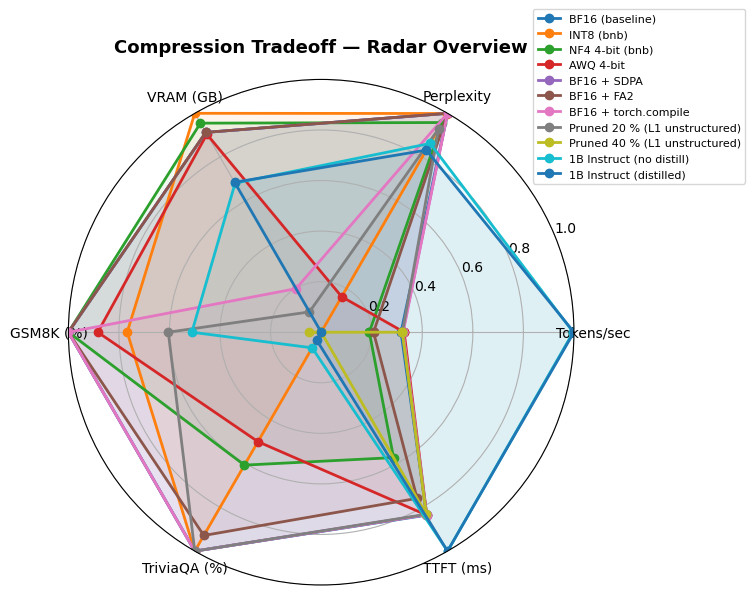

Saved to: outputs/radar_chart.png


In [45]:
# Radar chart — multi-metric overview
def radar_chart(df, metrics, title=""):
    """
    Plots a normalised radar chart for the given metrics.
    Each metric is normalised so that 1.0 = best observed value.
    For metrics where lower is better (PPL, VRAM, TTFT), we invert.
    """
    lower_is_better = {"Perplexity", "VRAM (GB)", "TTFT (ms)"}
    n_metrics = len(metrics)
    angles    = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
    angles   += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8),
                            subplot_kw=dict(polar=True))
    palette = sns.color_palette("tab10", n_colors=len(df))

    for (_, row), color in zip(df.iterrows(), palette):
        vals = []
        for m in metrics:
            v = row[m]
            if pd.isna(v):
                vals.append(0.0)
                continue
            col_min = df[m].min(); col_max = df[m].max()
            if col_max == col_min:
                vals.append(1.0)
            elif m in lower_is_better:
                vals.append(1 - (v - col_min) / (col_max - col_min))
            else:
                vals.append((v - col_min) / (col_max - col_min))
        vals += vals[:1]
        ax.plot(angles, vals, "-o", linewidth=2, color=color, label=row["Label"])
        ax.fill(angles, vals, alpha=0.07, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)
    plt.tight_layout()
    plt.savefig("radar_chart.png", dpi=150, bbox_inches="tight")
    plt.show()

RADAR_PATH = ROOT_DIR + "/radar_chart.png"
radar_metrics = ["Tokens/sec", "Perplexity", "VRAM (GB)", "GSM8K (%)", "TriviaQA (%)", "TTFT (ms)"]
radar_metrics = [m for m in radar_metrics if m in df.columns]
radar_chart(df.dropna(subset=["Perplexity"]), radar_metrics,
            title="Compression Tradeoff — Radar Overview")
print(f"Saved to: {RADAR_PATH}")

## 10. Deployment Recommendation

Recommendations below are derived directly from the measured benchmark results.

### Summary Table

| Deployment Scenario | Recommended Configuration | Rationale |
|---|---|---|
| Data-centre server — quality critical | BF16 baseline | Best overall balance: 68.13 tokens/sec, 10.01 perplexity, 67% GSM8K, 54% TriviaQA |
| Data-centre server — throughput optimised | BF16 + `torch.compile` | +8.5% throughput (73.88 vs 68.13 tokens/sec) at identical quality (10.002 perplexity) |
| Server with FlashAttention-2 capable GPU | BF16 + FA2 | ~70% TTFT reduction (19.3 ms vs 65.09 ms), accuracy unchanged (67% GSM8K) |
| Batch-serving (high concurrency) | NF4 4-bit + batching | 65.8% model size reduction (6.43 → 2.2 GB) enables higher batch sizes; 44.85 tokens/sec throughput |
| Edge / consumer GPU (≤ 8 GB VRAM) | NF4 4-bit | Fits reduced memory footprint at 6.89 GB VRAM with acceptable quality (10.534 perplexity, 67% GSM8K) |
| CPU-only deployment | 1B Instruct (no distill) | Strong CPU throughput (150.55 tokens/sec); reasoning accuracy is lower (46% GSM8K) |
| Reasoning / math-heavy workloads | BF16, or INT8 as minimum | INT8 preserves GSM8K (57%) while reducing VRAM to 5.44 GB |

### 10.1 Distillation Failure Mode (L1 → L0 Collapse)

The distilled model shows higher perplexity (10.01 → 12.112), a sharp GSM8K decline (67% → 26%), a TriviaQA decline (54% → 27%), and a reduced memory footprint. These outcomes match known failure patterns in aggressive teacher–student capacity reduction.

**Capacity bottleneck.** Reducing from 3B to 1B parameters underparameterizes the student for multi-step reasoning, compositional generalization, and long-range dependencies. Distillation under these conditions transfers local distributional statistics rather than algorithmic structure, which is why GSM8K — a structured-reasoning task — collapses.

**Objective mismatch.** The training mixture (GSM8K + Alpaca) does not align with TriviaQA, a factual-retrieval task. Teacher logits encode relative token plausibility under the teacher's own distribution, not factual grounding. The student inherits calibrated uncertainty rather than verified knowledge, which degrades knowledge-intensive performance.

**Entropy amplification.** Temperature scaling in KL-based distillation increases teacher-distribution entropy. This smooths gradients but narrows the margin between high-probability and near-probability tokens, weakening signal specificity for discrete reasoning steps — particularly damaging for arithmetic tasks that depend on sharp token-level distinctions.

**Exposure bias.** Inference remains autoregressive despite sequence-level training, so student-generated trajectories accumulate error relative to the lower-entropy teacher trajectories. These deviations compound across steps, disproportionately harming multi-step reasoning while leaving single-step fluency largely intact.

### 10.2 NF4 Quantization: Accuracy–Efficiency Trade-off

NF4 reduces VRAM substantially (6.43 GB → 2.2 GB) with a moderate perplexity increase (10.01 → 10.534) but a significant GSM8K decline (67% → 43%).

NF4 preserves outlier-aware scaling factors, maintaining principal activation subspaces and coarse-grained attention structure. It introduces quantization noise at the fine-grained logit level, which is what drives precise token ranking and stable argmax selection across intermediate reasoning steps. Distributional shape (perplexity) stays relatively stable while discrete decision fidelity deteriorates — explaining why GSM8K suffers more than the perplexity number alone would suggest.

### 10.3 FlashAttention-2: Latency vs. Throughput Decoupling

TTFT improves substantially (65 ms → ~19 ms), while token throughput stays roughly flat or dips slightly for short sequences.

FA2 reduces memory-bandwidth overhead through tiled attention and optimized kernels. For short sequences, kernel launch and orchestration overhead dominate and offset the gain; for long sequences, memory savings amortize into real throughput improvement. Gains are therefore sequence-length dependent, with TTFT improving more consistently than throughput.

### 10.4 `torch.compile`: Steady-State Optimization

Throughput improves by roughly 8.5%, but initial latency spikes (TTFT ~313 ms).

The upfront cost comes from graph capture, tracing, and kernel compilation. Once compiled, operator fusion, reduced interpreter overhead, and improved kernel scheduling produce the throughput gain. The benefit is realized in steady-state inference, not in cold-start or latency-sensitive scenarios.

### 10.5 Pruning: No Inference-Time Acceleration

Accuracy degrades severely (67% → 26%) with no measurable throughput improvement even at 40% sparsity.

This is a kernel limitation: dense GEMM kernels (e.g., cuBLAS) execute full matrix operations regardless of zero-valued weights, so unstructured sparsity is never exploited. Computational complexity is effectively unchanged while representational capacity is reduced — a pure accuracy loss with no corresponding runtime benefit.

### 10.6 System-Level Synthesis

Three operational regimes emerge from the results:

1. **Precision-constrained (BF16 / INT8)** — maximizes accuracy and reasoning fidelity with minimal structural distortion.
2. **Compression-oriented (NF4, pruning, distillation)** — optimizes memory efficiency but introduces nonlinear degradation in reasoning and factual recall, sensitive to task structure and supervision quality.
3. **Systems-optimized (FlashAttention-2, SDPA, `torch.compile`)** — preserves accuracy and improves hardware utilization, with gains that depend on workload and sequence length.

---
## 11. Reflection

### What surprised us?

Several results were different from what we expected.

A key surprise was the **weak link between perplexity and reasoning performance**. For NF4 quantization, perplexity only increased slightly (≈10.01 -> 10.53), but GSM8K accuracy dropped a lot (67% → 43%). This showed us that perplexity alone does not capture how well a model handles multi-step reasoning, where small changes in token probabilities can change the final answer.

Another surprise was the **lack of speedup from unstructured pruning (40%)**. Even though many weights were removed, runtime stayed almost the same because standard GPU kernels still run dense matrix operations. This meant that sparsity did not translate into real performance gains.

Finally, we found that **distillation hurt performance more than expected when reducing from 3B to 1B parameters**. The drop in reasoning ability was not gradual but quite sharp, especially on GSM8K, suggesting that some reasoning capabilities require a minimum model size to remain stable.

---

### What was harder than expected?

The hardest part of the project was the initial environment setup and getting all dependencies to work together correctly. At the beginning, even seemingly straightforward steps like installing the correct versions of PyTorch, CUDA-compatible libraries, and quantization backends led to repeated compatibility issues.

In particular, mismatches between CUDA versions, Triton wheels, and PyTorch builds caused non-obvious runtime errors and silent fallback behaviors that were difficult to diagnose. Several components (e.g., attention kernels, quantization libraries, and compilation tooling) had tight version coupling, which made incremental debugging slow and iterative.

A significant amount of time was spent resolving these configuration issues before any meaningful experimentation could begin, and this delayed the actual research and evaluation work more than initially anticipated.

---

---
## 12. Literature References & Appendices

**Quantization**
- Dettmers, T., Lewis, M., Belkada, Y., & Zettlemoyer, L. (2022). *LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale.* NeurIPS 2022.
- Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023). *QLoRA: Efficient Finetuning of Quantized LLMs.* NeurIPS 2023.
- Frantar, E., Ashkboos, S., Hoefler, T., & Alistarh, D. (2022). *GPTQ: Accurate Post-Training Quantization for Generative Pre-Trained Transformers.* arXiv:2210.17323.
- Lin, J., Tang, J., Tang, H., Yang, S., Dang, X., & Han, S. (2024). *AWQ: Activation-Aware Weight Quantization for LLM Compression and Acceleration.* MLSys 2024 Best Paper.

**Attention & Systems**
- Dao, T. (2023). *FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning.* ICLR 2024.
- Ansel, J., Yang, E., He, H., Gimelshein, N., Jain, A., Voznesensky, M., … Chintala, S. (2024). *PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation.* ASPLOS 2024.

**Pruning**
- Ma, X., Fang, G., & Wang, X. (2023). *LLM-Pruner: On the Structural Pruning of Large Language Models.* NeurIPS 2023.

**Knowledge Distillation**
- Hinton, G., Vinyals, O., & Dean, J. (2015). *Distilling the Knowledge in a Neural Network.* arXiv:1503.02531.

**Tools & Infrastructure**
- Gerganov, G. (2023). *llama.cpp.* https://github.com/ggerganov/llama.cpp
- EleutherAI (2021). *lm-evaluation-harness.* https://github.com/EleutherAI/lm-evaluation-harness
- Cobbzilla, M. (2024). *bitsandbytes CUDA 12.1 support.* https://github.com/TimDettmers/bitsandbytes

**Datasets**
- Merity, S., Xiong, C., Bradbury, J., & Socher, R. (2017). *Pointer Sentinel Mixture Models (WikiText-2).* ICLR 2017.
- Cobbe, K., Kosaraju, V., Bavarian, M., Hilton, J., Nakano, R., Hesse, C., & Schulman, J. (2021). *Training Verifiers to Solve Math Word Problems (GSM8K).* arXiv:2110.14168.
- Joshi, M., Choi, E., Weld, D., & Zettlemoyer, L. (2017). *TriviaQA: A Large Scale Distantly Supervised Challenge Dataset for Reading Comprehension.* ACL 2017.
